In [ ]:
# # Phase 7 — Whole Blood Smear XAI Analysis

# ## Objective

# This notebook analyzes a whole blood-smear microscopy image using:

# 1. Cellpose — cell segmentation
# 2. ResNet50 — cell classification
# 3. Grad-CAM — visual explanation
# 4. SHAP — feature attribution
# 5. ReportLab — automated XAI PDF report

# ### Pipeline

# Whole blood smear
# → Cellpose segmentation
# → Individual cell extraction
# → ResNet50 classification
# → Cell-level predictions
# → Whole-smear analysis
# → Grad-CAM / SHAP
# → XAI PDF report

# ### Model

# The trained ResNet50 model from Phase 4 is used without retraining.

# Input size: 384 × 384

# Classes:
# - basophil
# - erythroblast
# - monocyte
# - myeloblast
# - seg_neutrophil

# ### Important

# This is a research-oriented image-analysis and explainability pipeline.
# The generated results are not a clinical diagnosis of leukemia or cancer.

In [3]:
import sys
import subprocess

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "opencv-python",
    "Pillow",
    "tensorflow",
    "cellpose",
    "scikit-image",
    "reportlab"
]

for package in packages:
    print(f"\nChecking: {package}")
    
    result = subprocess.run(
        [sys.executable, "-m", "pip", "show", package],
        capture_output=True,
        text=True
    )
    
    if result.returncode == 0:
        print("Installed")
    else:
        print("NOT FOUND")


Checking: numpy
Installed

Checking: pandas
Installed

Checking: matplotlib
Installed

Checking: opencv-python
Installed

Checking: Pillow
Installed

Checking: tensorflow
Installed

Checking: cellpose
Installed

Checking: scikit-image
Installed

Checking: reportlab
Installed


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from tensorflow.keras.applications.resnet50 import preprocess_input

from cellpose import models

from skimage.measure import regionprops

from reportlab.lib.pagesizes import A4
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image as RLImage,
    Table,
    TableStyle,
    PageBreak
)

from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch

print("All imports successful.")

2026-09-07 15:42:25.580335: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-07 15:42:25.637075: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All imports successful.


In [12]:
# ==========================================
# PHASE 7 CONFIGURATION
# ==========================================

IMG_SIZE = (384, 384)

CLASS_NAMES = [
    "basophil",
    "erythroblast",
    "monocyte",
    "myeloblast",
    "seg_neutrophil"
]

MODEL_PATH = "../models/resnet50_frozen_384.keras"

# Change this to the blood-smear image you want to analyze
SMEAR_PATH = "../images/myo4.jpeg"

OUTPUT_DIR = "../images/phase7_xai_report"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded.")
print("Model:", MODEL_PATH)
print("Smear:", SMEAR_PATH)
print("Output:", OUTPUT_DIR)
print("Image size:", IMG_SIZE)
print("Classes:", CLASS_NAMES)

Configuration loaded.
Model: ../models/resnet50_frozen_384.keras
Smear: ../images/myo4.jpeg
Output: ../images/phase7_xai_report
Image size: (384, 384)
Classes: ['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']


In [13]:
# ==========================================
# LOAD TRAINED RESNET50
# ==========================================

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model not found:\n{MODEL_PATH}\n\n"
        "Check the MODEL_PATH."
    )

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully.")
print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)

Model loaded successfully.
Input shape : (None, 384, 384, 3)
Output shape: (None, 5)


In [14]:
layer_names = [layer.name for layer in model.layers]

for i, name in enumerate(layer_names):
    print(i, name)

0 resnet50
1 global_average_pooling2d_1
2 dropout_2
3 dense_2
4 dropout_3
5 dense_3


In [15]:
base_model = model.get_layer("resnet50")

print("Base model:", base_model.name)
print("Number of layers:", len(base_model.layers))

for i, layer in enumerate(base_model.layers[-15:]):
    print(i - 15, layer.name, layer.output.shape)

Base model: resnet50
Number of layers: 175
-15 conv5_block2_2_relu (None, 12, 12, 512)
-14 conv5_block2_3_conv (None, 12, 12, 2048)
-13 conv5_block2_3_bn (None, 12, 12, 2048)
-12 conv5_block2_add (None, 12, 12, 2048)
-11 conv5_block2_out (None, 12, 12, 2048)
-10 conv5_block3_1_conv (None, 12, 12, 512)
-9 conv5_block3_1_bn (None, 12, 12, 512)
-8 conv5_block3_1_relu (None, 12, 12, 512)
-7 conv5_block3_2_conv (None, 12, 12, 512)
-6 conv5_block3_2_bn (None, 12, 12, 512)
-5 conv5_block3_2_relu (None, 12, 12, 512)
-4 conv5_block3_3_conv (None, 12, 12, 2048)
-3 conv5_block3_3_bn (None, 12, 12, 2048)
-2 conv5_block3_add (None, 12, 12, 2048)
-1 conv5_block3_out (None, 12, 12, 2048)


In [17]:
TARGET_LAYER = "conv5_block3_out"

target_layer = base_model.get_layer(TARGET_LAYER)

print("Found target layer:", target_layer.name)
print("Output shape:", target_layer.output.shape)

Found target layer: conv5_block3_out
Output shape: (None, 12, 12, 2048)


In [18]:
if not os.path.exists(SMEAR_PATH):
    print("Smear image not found yet.")
    print("Current path:")
    print(SMEAR_PATH)
else:
    print("Smear found:")
    print(SMEAR_PATH)

Smear found:
../images/myo4.jpeg


Smear loaded successfully.
Width : 250
Height: 209
Channels: 3


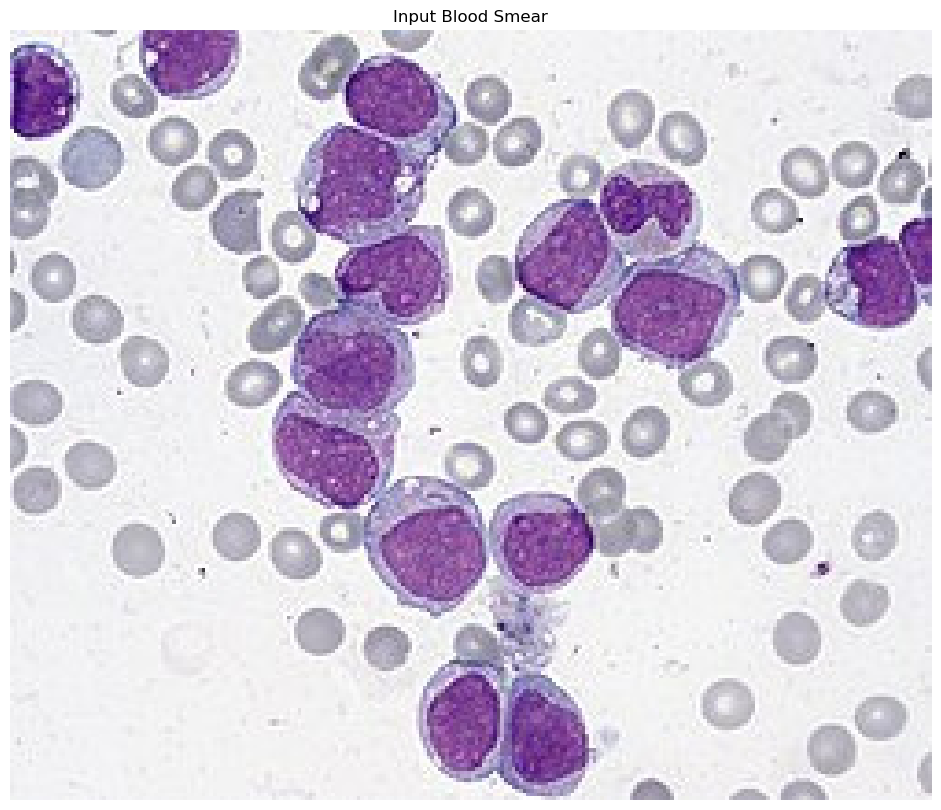

In [19]:
smear_bgr = cv2.imread(SMEAR_PATH)

if smear_bgr is None:
    raise ValueError(
        f"OpenCV could not read:\n{SMEAR_PATH}"
    )

smear_rgb = cv2.cvtColor(
    smear_bgr,
    cv2.COLOR_BGR2RGB
)

print("Smear loaded successfully.")
print("Width :", smear_rgb.shape[1])
print("Height:", smear_rgb.shape[0])
print("Channels:", smear_rgb.shape[2])

plt.figure(figsize=(14, 10))
plt.imshow(smear_rgb)
plt.axis("off")
plt.title("Input Blood Smear")
plt.show()

In [20]:
base_model = model.get_layer("resnet50")

TARGET_LAYER = "conv5_block3_out"
target_layer = base_model.get_layer(TARGET_LAYER)

print("Target layer:", target_layer.name)
print("Output shape:", target_layer.output.shape)

Target layer: conv5_block3_out
Output shape: (None, 12, 12, 2048)


Smear shape: (209, 250, 3)
Smear dtype: uint8


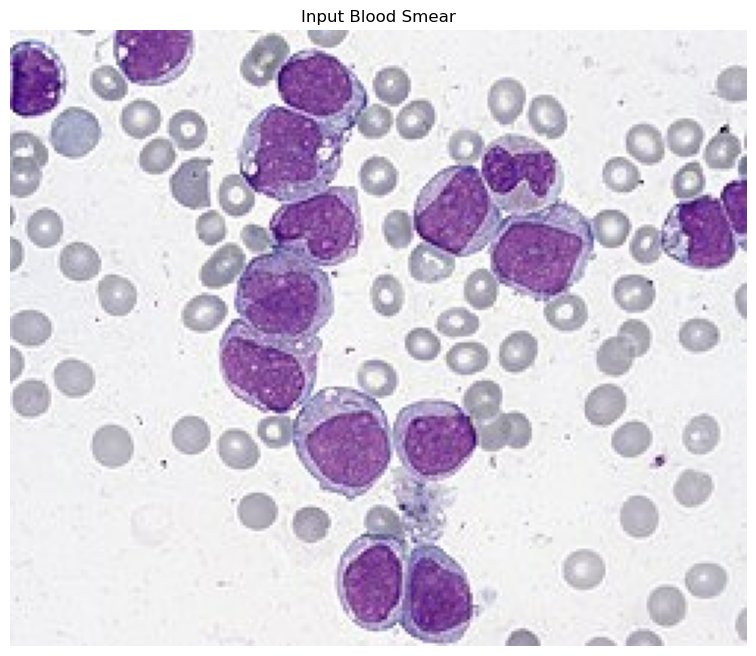

In [23]:
print("Smear shape:", smear_bgr.shape)
print("Smear dtype:", smear_bgr.dtype)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(smear_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Input Blood Smear")
plt.show()

In [24]:
from cellpose import models
import numpy as np
import matplotlib.pyplot as plt

# Load Cellpose model
cellpose_model = models.CellposeModel(
    gpu=False,
    model_type="cpsam"
)

# Cellpose channels
channels = [0, 0]

# Segment the smear
masks, flows, styles = cellpose_model.eval(
    smear_bgr,
    channels=channels
)

num_objects = int(masks.max())

print("Number of segmented objects:", num_objects)
print("Mask shape:", masks.shape)

/home/sahil/miniconda3/envs/ds/lib/python3.13/site-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:848.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


Number of segmented objects: 83
Mask shape: (209, 250)


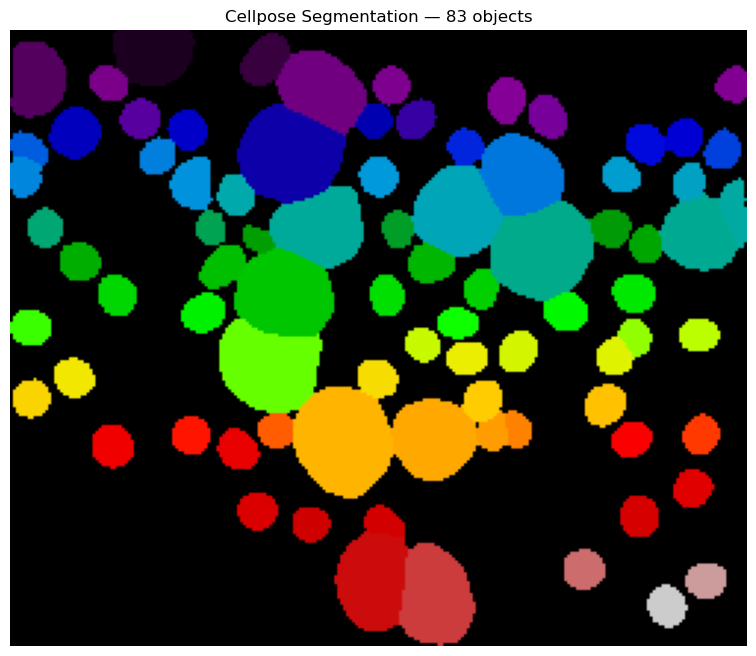

In [25]:
plt.figure(figsize=(12, 8))

plt.imshow(masks, cmap="nipy_spectral")

plt.axis("off")
plt.title(f"Cellpose Segmentation — {num_objects} objects")

plt.show()

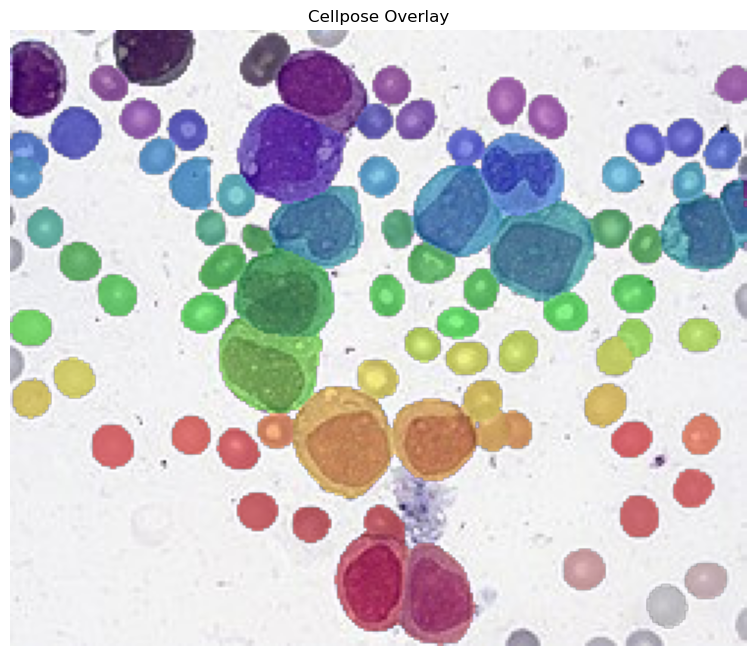

In [26]:
plt.figure(figsize=(12, 8))

plt.imshow(cv2.cvtColor(smear_bgr, cv2.COLOR_BGR2RGB))
plt.imshow(
    np.ma.masked_where(masks == 0, masks),
    cmap="nipy_spectral",
    alpha=0.45
)

plt.axis("off")
plt.title("Cellpose Overlay")

plt.show()

In [27]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Store individual cell crops
cell_crops = []
cell_info = []

num_objects = int(masks.max())

for cell_id in range(1, num_objects + 1):

    # Pixels belonging to this cell
    ys, xs = np.where(masks == cell_id)

    if len(xs) == 0:
        continue

    # Bounding box
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    # Small padding around cell
    pad = 10

    x1p = max(0, x1 - pad)
    y1p = max(0, y1 - pad)
    x2p = min(smear_bgr.shape[1], x2 + pad + 1)
    y2p = min(smear_bgr.shape[0], y2 + pad + 1)

    crop = smear_bgr[y1p:y2p, x1p:x2p].copy()

    # Corresponding mask
    crop_mask = (masks[y1p:y2p, x1p:x2p] == cell_id)

    # Clean background:
    # replace everything outside the selected cell with white
    clean_crop = crop.copy()
    clean_crop[~crop_mask] = 255

    # Cell area
    area = int(np.sum(crop_mask))

    # Bounding-box dimensions
    width = x2 - x1 + 1
    height = y2 - y1 + 1

    # Keep the crop
    cell_crops.append(clean_crop)

    cell_info.append({
        "cell_id": cell_id,
        "area": area,
        "x": int(x1),
        "y": int(y1),
        "width": int(width),
        "height": int(height)
    })

cell_df = pd.DataFrame(cell_info)

print("Total clean cell crops:", len(cell_crops))
print(cell_df.head())

Total clean cell crops: 83
   cell_id  area   x   y  width  height
0        1   446  35   0     28      19
1        2   216  78   1     17      18
2        3   401   0   4     19      26
3        4   598  90   7     31      29
4        5   126  27  12     13      12


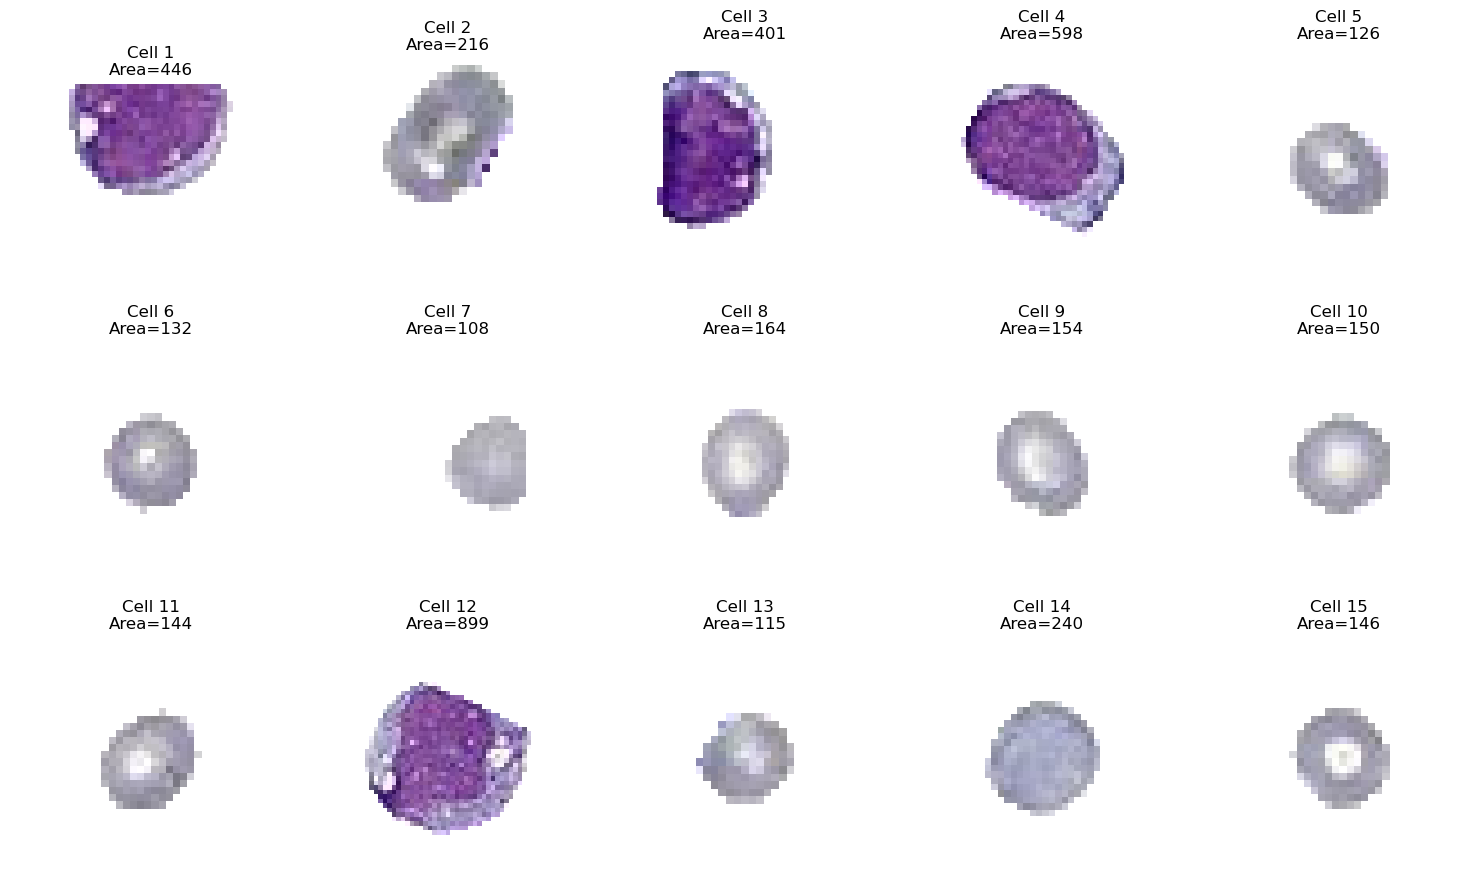

In [28]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for ax, crop, info in zip(axes.flat, cell_crops[:15], cell_info[:15]):
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Cell {info['cell_id']}\nArea={info['area']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [29]:
# ============================================
# ResNet50 classification of Cellpose crops
# ============================================

from tensorflow.keras.applications.resnet50 import preprocess_input

CLASS_NAMES = [
    "basophil",
    "erythroblast",
    "monocyte",
    "myeloblast",
    "seg_neutrophil"
]

IMG_SIZE = 384


def prepare_cell(crop):
    """
    Resize a cell crop while preserving aspect ratio.
    Remaining area is padded with white.
    """

    h, w = crop.shape[:2]

    scale = min(IMG_SIZE / w, IMG_SIZE / h)

    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    resized = cv2.resize(
        crop,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    # White canvas
    canvas = np.ones(
        (IMG_SIZE, IMG_SIZE, 3),
        dtype=np.uint8
    ) * 255

    # Center the cell
    x_offset = (IMG_SIZE - new_w) // 2
    y_offset = (IMG_SIZE - new_h) // 2

    canvas[
        y_offset:y_offset + new_h,
        x_offset:x_offset + new_w
    ] = resized

    return canvas


# Prepare all cells
X = np.stack([
    prepare_cell(crop)
    for crop in cell_crops
])

print("Prepared batch:", X.shape)

# ResNet50 preprocessing
X_preprocessed = preprocess_input(
    X.astype(np.float32)
)

# Prediction
predictions = model.predict(
    X_preprocessed,
    batch_size=16,
    verbose=1
)

predicted_indices = np.argmax(predictions, axis=1)
predicted_classes = [
    CLASS_NAMES[i]
    for i in predicted_indices
]

confidences = np.max(predictions, axis=1)


# Add predictions to dataframe
cell_df["predicted_class"] = predicted_classes
cell_df["confidence"] = confidences


# Display results
results = cell_df[
    [
        "cell_id",
        "area",
        "predicted_class",
        "confidence"
    ]
].copy()

results["confidence"] = (
    results["confidence"] * 100
).round(2)

print(results.to_string(index=False))

Prepared batch: (83, 384, 384, 3)


2026-09-07 16:06:11.349549: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f137401afa0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-09-07 16:06:11.349654: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2026-09-07 16:06:11.477429: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788777373.389463  599693 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6/6 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step
 cell_id  area predicted_class  confidence
       1   446      myeloblast   77.500000
       2   216        basophil   88.500000
       3   401        basophil   97.480003
       4   598      myeloblast   90.379997
       5   126    erythroblast   96.839996
       6   132    erythroblast   93.430000
       7   108    erythroblast   99.330002
       8   164    erythroblast   98.959999
       9   154    erythroblast   82.360001
      10   150    erythroblast   97.629997
      11   144    erythroblast   95.139999
      12   899        basophil   82.209999
      13   115    erythroblast   74.199997
      14   240    erythroblast   82.889999
      15   146    erythroblast   89.500000
      16   136    erythroblast   98.400002
      17   146    erythroblast   97.800003
      18   124    erythroblast   95.209999
      19   131    erythroblast   99.870003
      20   101    erythroblast   99.910004
      21   607        basophil   98.169998
      22   125   

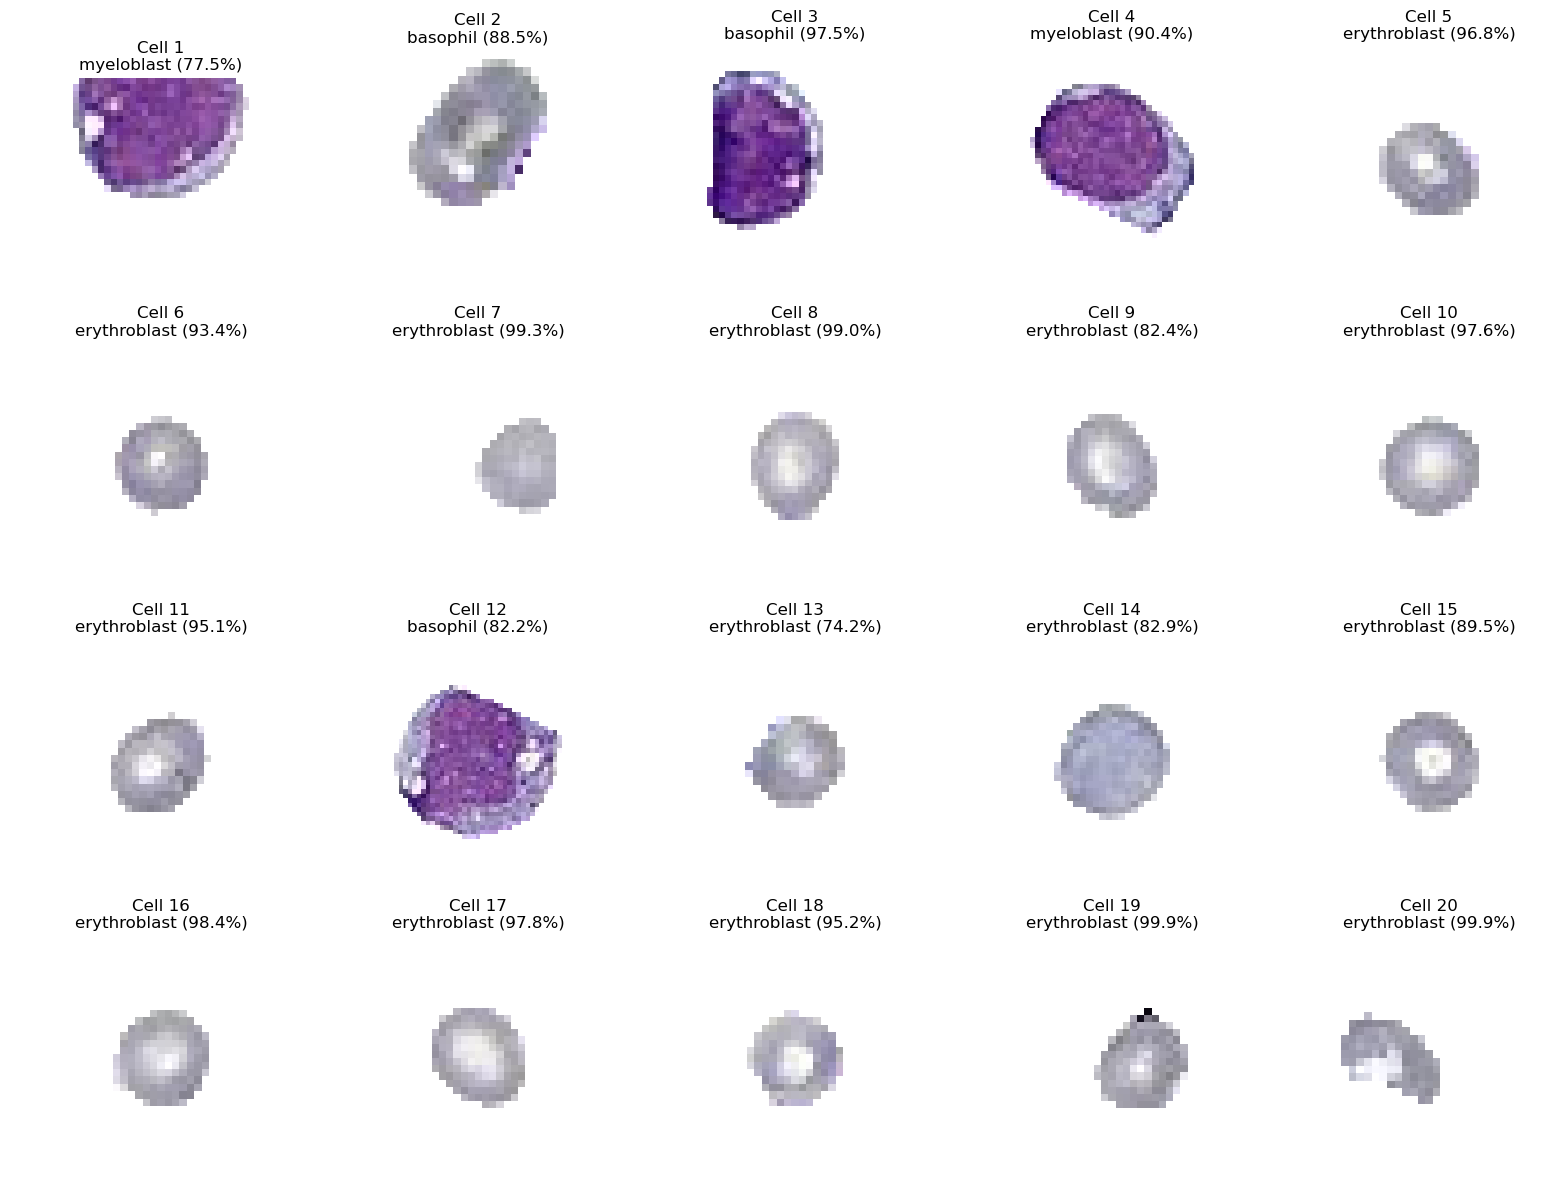

In [30]:
fig, axes = plt.subplots(4, 5, figsize=(16, 12))

for ax, crop, info in zip(
    axes.flat,
    cell_crops[:20],
    cell_info[:20]
):

    cell_id = info["cell_id"]

    row = cell_df[
        cell_df["cell_id"] == cell_id
    ].iloc[0]

    label = row["predicted_class"]
    conf = row["confidence"] * 100

    ax.imshow(
        cv2.cvtColor(
            crop,
            cv2.COLOR_BGR2RGB
        )
    )

    ax.set_title(
        f"Cell {cell_id}\n"
        f"{label} ({conf:.1f}%)"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [32]:
# ============================================
# Detect nucleated-cell candidates
# ============================================

def calculate_purple_score(crop):
    """
    Estimate how strongly the crop contains
    purple/blue cellular material.

    Higher score = more likely nucleated-cell
    appearance in this smear.
    """

    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    r = rgb[:, :, 0].astype(np.float32)
    g = rgb[:, :, 1].astype(np.float32)
    b = rgb[:, :, 2].astype(np.float32)

    # Purple/blue material tends to have relatively
    # stronger blue/red components than green.
    purple = ((r + b) / 2) - g

    # Ignore the white background
    foreground = np.mean(rgb, axis=2) < 245

    if np.sum(foreground) == 0:
        return 0

    score = np.mean(purple[foreground])

    return float(score)


purple_scores = []

for crop in cell_crops:
    purple_scores.append(
        calculate_purple_score(crop)
    )

cell_df["purple_score"] = purple_scores

# Display all objects sorted by purple score
candidate_table = cell_df[
    [
        "cell_id",
        "area",
        "purple_score",
        "predicted_class",
        "confidence"
    ]
].copy()

candidate_table["confidence"] *= 100

candidate_table = candidate_table.sort_values(
    "purple_score",
    ascending=False
)

print(
    candidate_table.to_string(index=False)
)

 cell_id  area  purple_score predicted_class  confidence
      30   149     60.177853    erythroblast   87.728088
       3   401     57.119347        basophil   97.475388
       1   446     53.456619      myeloblast   77.501831
      31   647     52.833591      myeloblast   89.189819
       4   598     52.029362      myeloblast   90.378342
      32   500     51.493965        basophil   55.457764
      80   689     51.069969      myeloblast   71.219894
      65   631     50.246033      myeloblast   93.275513
      43   795     49.247482        basophil   90.996765
      79   658     49.210686      myeloblast   65.763474
      28   697     49.134338      myeloblast   69.301376
      52   822     48.797546      myeloblast   87.530602
      33   895     47.401234      myeloblast   90.466232
      12   899     47.025597        basophil   82.212013
      64   989     43.818737        basophil   98.951958
      21   607     42.339138        basophil   98.173897
      24   204     11.865000   

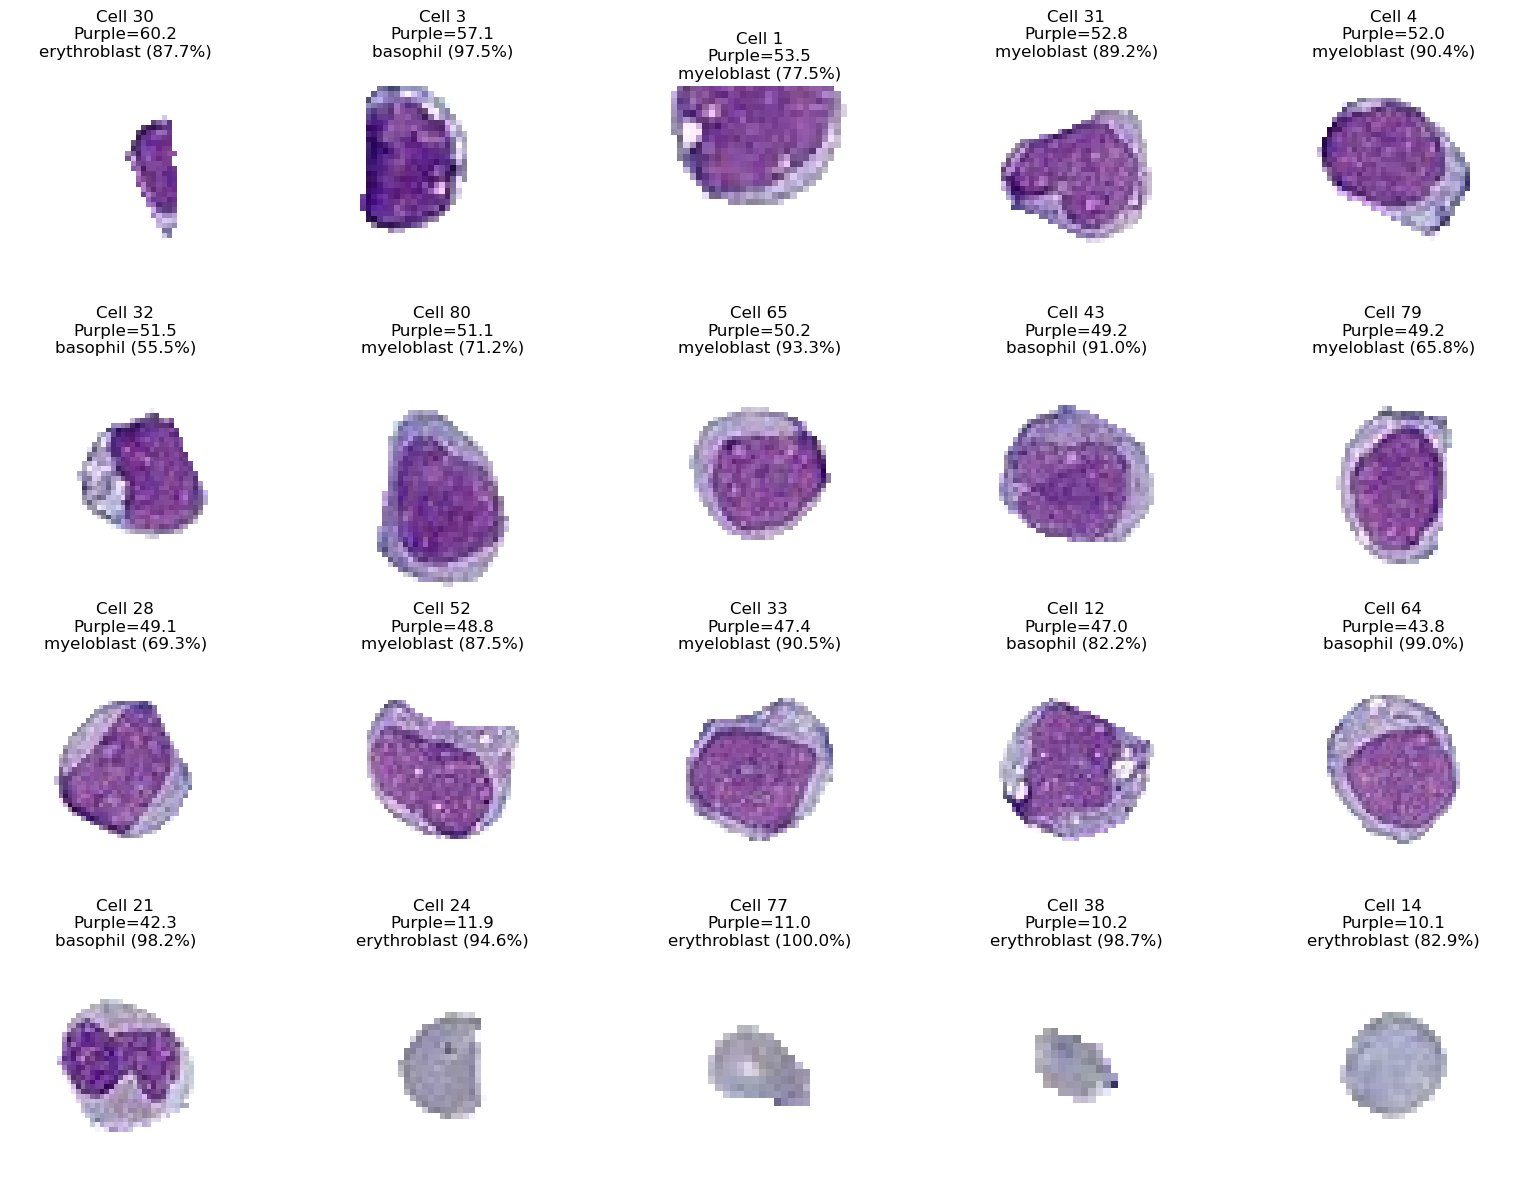

In [33]:
# ============================================
# Show most purple / nucleated-cell candidates
# ============================================

top_ids = (
    cell_df
    .sort_values("purple_score", ascending=False)
    .head(20)["cell_id"]
    .tolist()
)

fig, axes = plt.subplots(4, 5, figsize=(16, 12))

for ax, cell_id in zip(axes.flat, top_ids):

    idx = cell_df.index[
        cell_df["cell_id"] == cell_id
    ][0]

    crop = cell_crops[idx]
    row = cell_df.loc[idx]

    ax.imshow(
        cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    )

    ax.set_title(
        f"Cell {cell_id}\n"
        f"Purple={row['purple_score']:.1f}\n"
        f"{row['predicted_class']} "
        f"({row['confidence']*100:.1f}%)"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [36]:
# ============================================
# Select nucleated-cell candidates
# ============================================

PURPLE_THRESHOLD = 35.0

candidate_df = cell_df[
    cell_df["purple_score"] >= PURPLE_THRESHOLD
].copy()

candidate_df = candidate_df.sort_values(
    "purple_score",
    ascending=False
)

print("Total Cellpose objects:", len(cell_df))
print("Nucleated-cell candidates:", len(candidate_df))

print("\nCandidates:")
print(
    candidate_df[
        [
            "cell_id",
            "area",
            "purple_score",
            "predicted_class",
            "confidence"
        ]
    ].to_string(index=False)
)

Total Cellpose objects: 83
Nucleated-cell candidates: 16

Candidates:
 cell_id  area  purple_score predicted_class  confidence
      30   149     60.177853    erythroblast    0.877281
       3   401     57.119347        basophil    0.974754
       1   446     53.456619      myeloblast    0.775018
      31   647     52.833591      myeloblast    0.891898
       4   598     52.029362      myeloblast    0.903783
      32   500     51.493965        basophil    0.554578
      80   689     51.069969      myeloblast    0.712199
      65   631     50.246033      myeloblast    0.932755
      43   795     49.247482        basophil    0.909968
      79   658     49.210686      myeloblast    0.657635
      28   697     49.134338      myeloblast    0.693014
      52   822     48.797546      myeloblast    0.875306
      33   895     47.401234      myeloblast    0.904662
      12   899     47.025597        basophil    0.822120
      64   989     43.818737        basophil    0.989520
      21   607    

In [37]:
# ============================================
# Select myeloblast-like candidates
# ============================================

myeloblast_df = candidate_df[
    candidate_df["predicted_class"] == "myeloblast"
].copy()

myeloblast_df = myeloblast_df.sort_values(
    "confidence",
    ascending=False
)

print(
    "Myeloblast-like candidates:",
    len(myeloblast_df)
)

print(
    myeloblast_df[
        [
            "cell_id",
            "area",
            "purple_score",
            "confidence"
        ]
    ].to_string(index=False)
)

Myeloblast-like candidates: 9
 cell_id  area  purple_score  confidence
      65   631     50.246033    0.932755
      33   895     47.401234    0.904662
       4   598     52.029362    0.903783
      31   647     52.833591    0.891898
      52   822     48.797546    0.875306
       1   446     53.456619    0.775018
      80   689     51.069969    0.712199
      28   697     49.134338    0.693014
      79   658     49.210686    0.657635


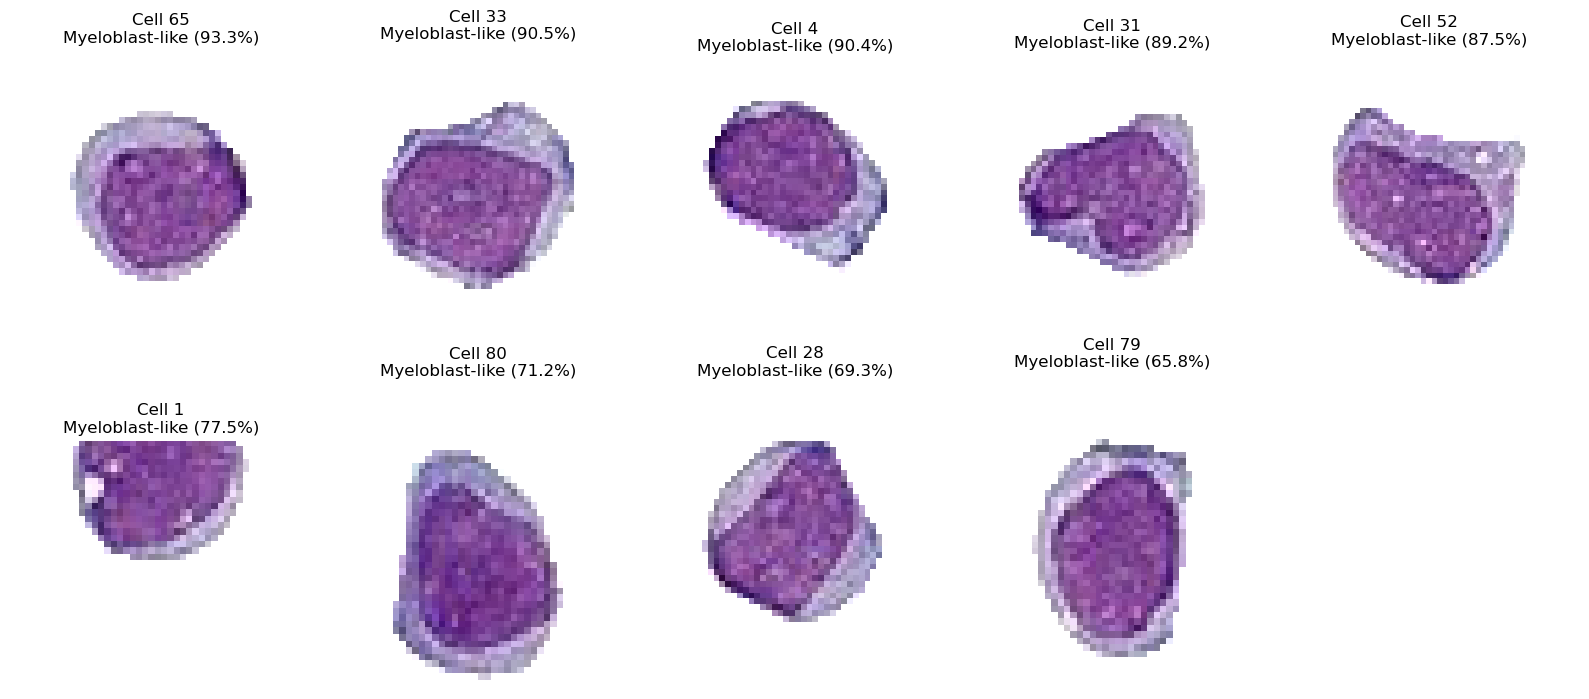

In [38]:
# ============================================
# Visualize myeloblast-like candidates
# ============================================

selected_ids = myeloblast_df["cell_id"].tolist()

if len(selected_ids) == 0:
    print("No myeloblast-like candidates found.")

else:
    cols = 5
    rows = int(np.ceil(len(selected_ids) / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(16, 3.5 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, cell_id in zip(axes, selected_ids):

        idx = cell_df.index[
            cell_df["cell_id"] == cell_id
        ][0]

        crop = cell_crops[idx]
        row = cell_df.loc[idx]

        ax.imshow(
            cv2.cvtColor(
                crop,
                cv2.COLOR_BGR2RGB
            )
        )

        ax.set_title(
            f"Cell {cell_id}\n"
            f"Myeloblast-like "
            f"({row['confidence']*100:.1f}%)"
        )

        ax.axis("off")

    for ax in axes[len(selected_ids):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [39]:
# ============================================
# Verify Grad-CAM target layer
# ============================================

base_model = model.get_layer("resnet50")

TARGET_LAYER = "conv5_block3_out"

target_layer = base_model.get_layer(
    TARGET_LAYER
)

print("Base model:", base_model.name)
print("Target layer:", target_layer.name)
print("Target output:", target_layer.output.shape)

Base model: resnet50
Target layer: conv5_block3_out
Target output: (None, 12, 12, 2048)


In [48]:
# ============================================
# GRAD-CAM FOR YOUR SAVED RESNET50 MODEL
# ============================================

base_model = model.get_layer("resnet50")

target_layer = base_model.get_layer(
    "conv5_block3_out"
)

gap_layer = model.get_layer(
    "global_average_pooling2d_1"
)

dropout1 = model.get_layer(
    "dropout_2"
)

dense1 = model.get_layer(
    "dense_2"
)

dropout2 = model.get_layer(
    "dropout_3"
)

dense2 = model.get_layer(
    "dense_3"
)

print("Base model:", base_model.name)
print("Target layer:", target_layer.name)
print("Target shape:", target_layer.output.shape)

Base model: resnet50
Target layer: conv5_block3_out
Target shape: (None, 12, 12, 2048)


In [51]:
# ============================================
# Build a standalone ResNet50 feature model
# ============================================

feature_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=target_layer.output
)

print("Feature model created successfully.")
print("Feature output:", feature_model.output.shape)

Feature model created successfully.
Feature output: (None, 12, 12, 2048)


In [52]:
# ============================================
# Test feature extraction
# ============================================

test_image = X[0:1].astype(np.float32)

test_image = preprocess_input(test_image)

features = feature_model(
    test_image,
    training=False
)

print("Feature shape:", features.shape)

Feature shape: (1, 12, 12, 2048)


In [53]:
# ============================================
# Final Grad-CAM function
# ============================================

def generate_gradcam(image, class_index):

    with tf.GradientTape() as tape:

        # Get convolutional feature maps
        conv_outputs = feature_model(
            image,
            training=False
        )

        # Use the existing classification head
        x = tf.reduce_mean(
            conv_outputs,
            axis=[1, 2]
        )

        x = model.get_layer(
            "dropout_2"
        )(x, training=False)

        x = model.get_layer(
            "dense_2"
        )(x)

        x = model.get_layer(
            "dropout_3"
        )(x, training=False)

        predictions_out = model.get_layer(
            "dense_3"
        )(x)

        class_score = predictions_out[:, class_index]

    # Gradient of class score with respect
    # to convolutional feature maps
    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    # Average gradients spatially
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weighted feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Keep positive contributions
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    heatmap = heatmap / (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()

print("Grad-CAM function ready.")

Grad-CAM function ready.


In [54]:
# ============================================
# TEST GRAD-CAM ON ONE MYELOBLAST CANDIDATE
# ============================================

if len(myeloblast_df) == 0:
    print("No myeloblast-like candidates found.")
else:

    # Take highest-confidence candidate
    row = myeloblast_df.iloc[0]

    cell_id = int(row["cell_id"])

    # Find its position in cell_crops / X
    idx = cell_df.index[
        cell_df["cell_id"] == cell_id
    ][0]

    # Original 384x384 image
    image = X[idx].copy()

    # ResNet50 preprocessing
    image_input = preprocess_input(
        image.astype(np.float32)
    )

    image_input = np.expand_dims(
        image_input,
        axis=0
    )

    # Predicted class
    class_index = int(
        np.argmax(predictions[idx])
    )

    class_name = CLASS_NAMES[class_index]
    confidence = predictions[idx][class_index]

    print("Cell ID:", cell_id)
    print("Predicted class:", class_name)
    print("Confidence:", f"{confidence*100:.2f}%")

    # Generate Grad-CAM
    heatmap = generate_gradcam(
        image_input,
        class_index
    )

    print("Heatmap shape:", heatmap.shape)

Cell ID: 65
Predicted class: myeloblast
Confidence: 93.28%
Heatmap shape: (12, 12)


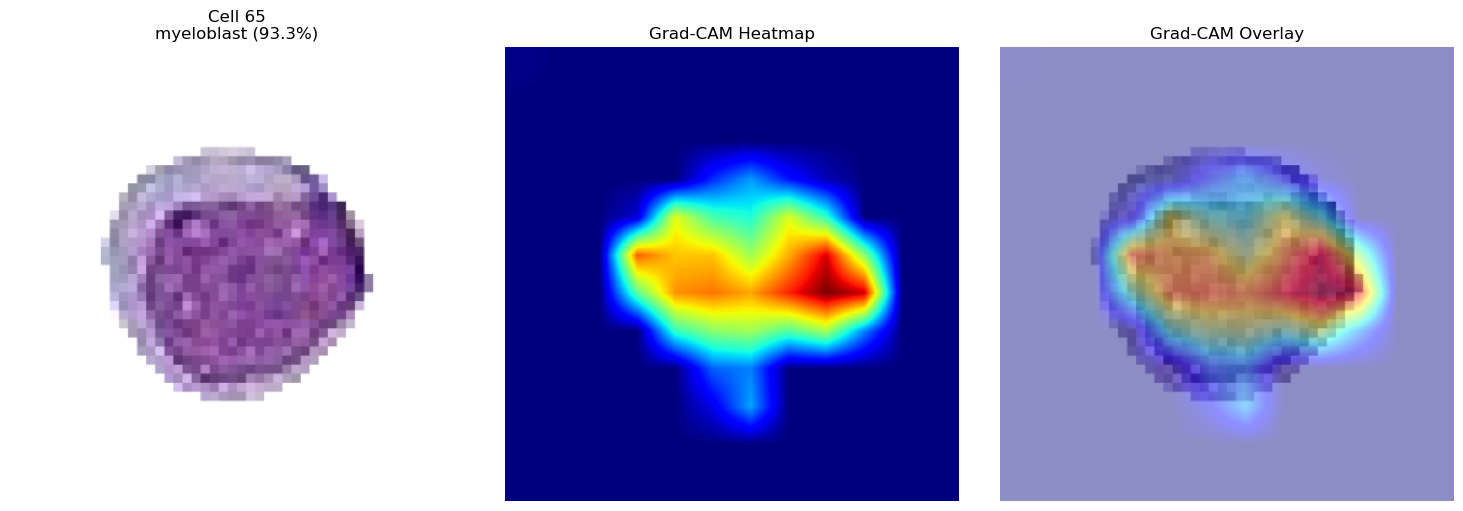

In [55]:
# ============================================
# VISUALIZE TEST GRAD-CAM
# ============================================

heatmap_resized = cv2.resize(
    heatmap,
    (384, 384),
    interpolation=cv2.INTER_LINEAR
)

original_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(original_rgb)
plt.title(
    f"Cell {cell_id}\n"
    f"{class_name} ({confidence*100:.1f}%)"
)
plt.axis("off")

# Heatmap
plt.subplot(1, 3, 2)
plt.imshow(
    heatmap_resized,
    cmap="jet"
)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(original_rgb)
plt.imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.45
)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

Generating Grad-CAM for cells: [65, 33, 4, 31, 52, 1]


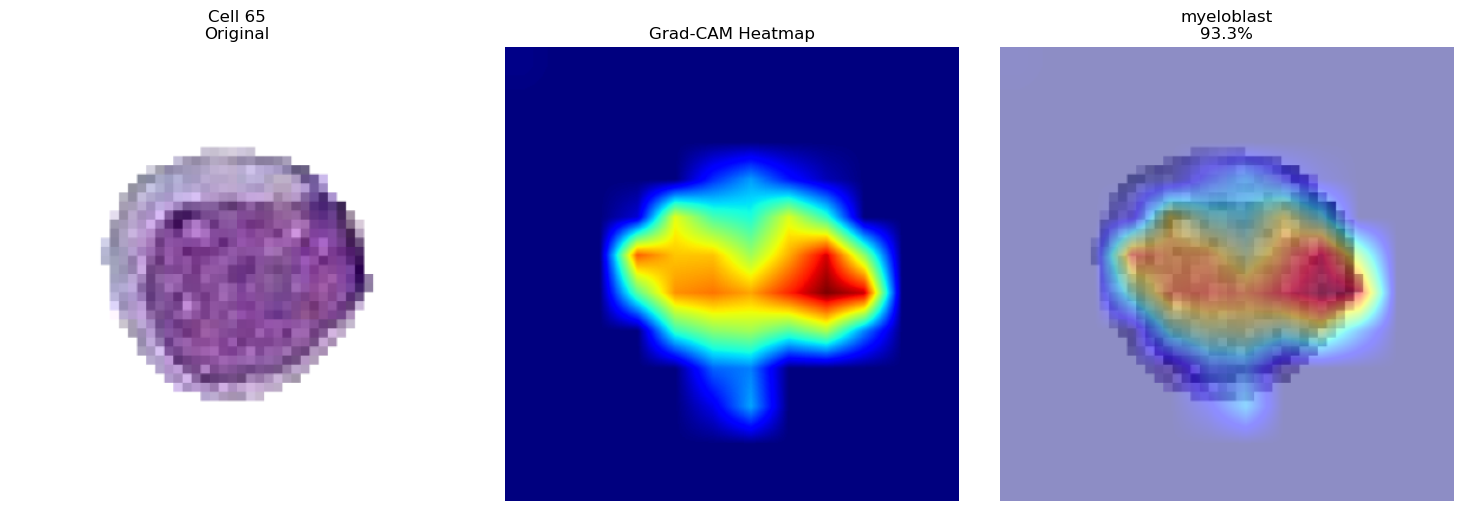

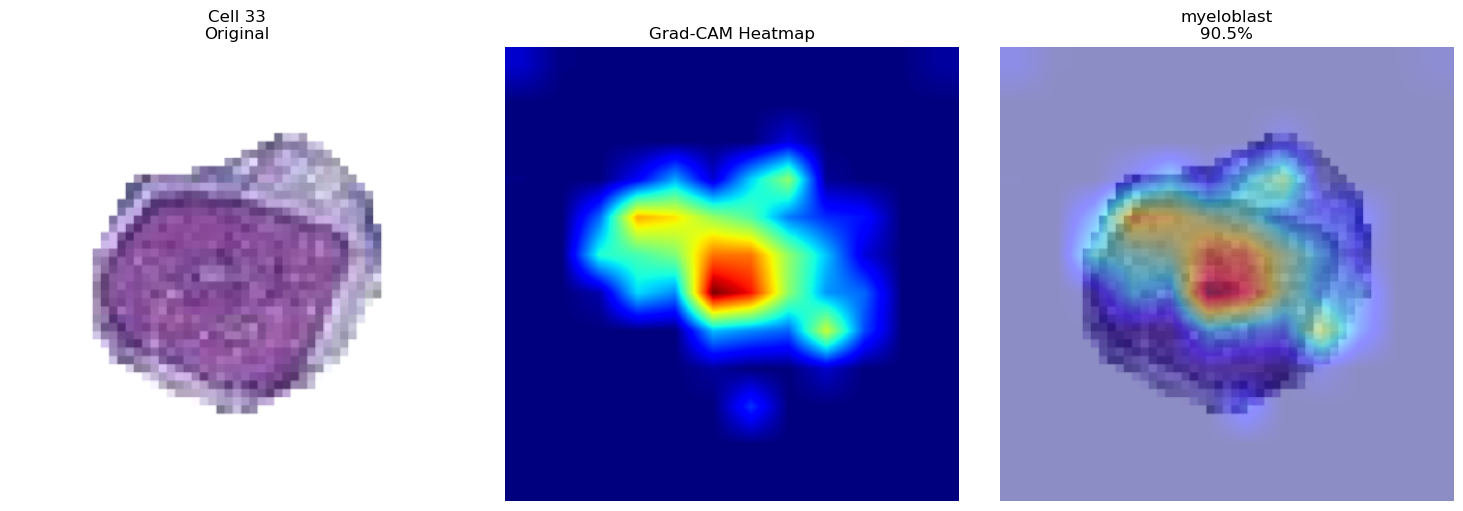

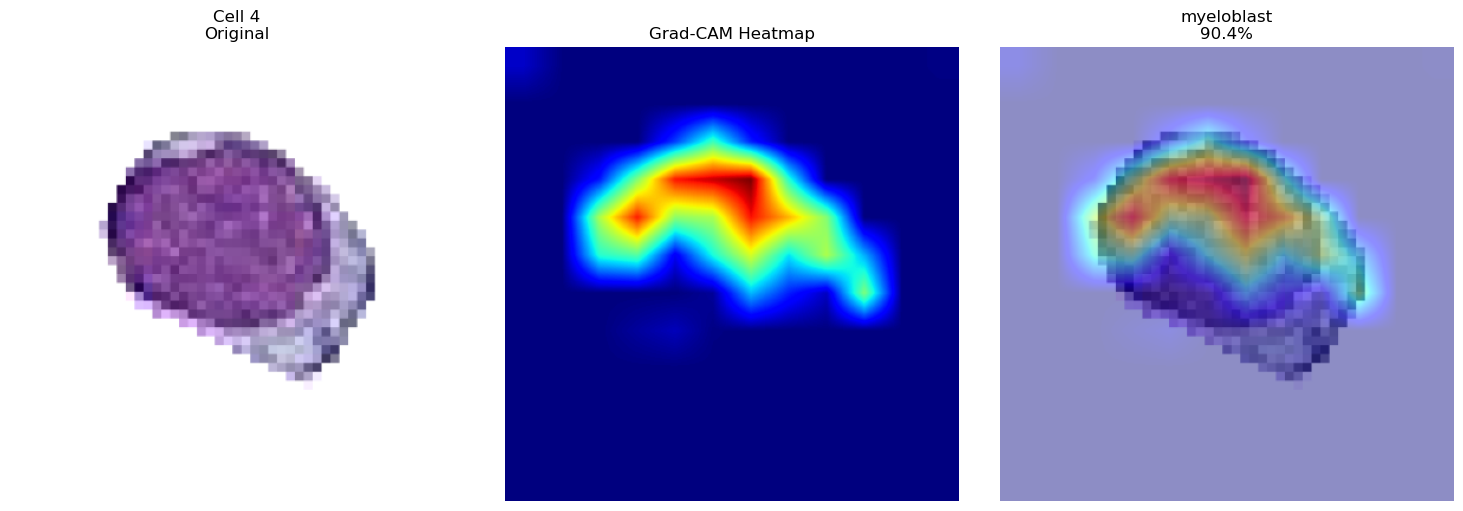

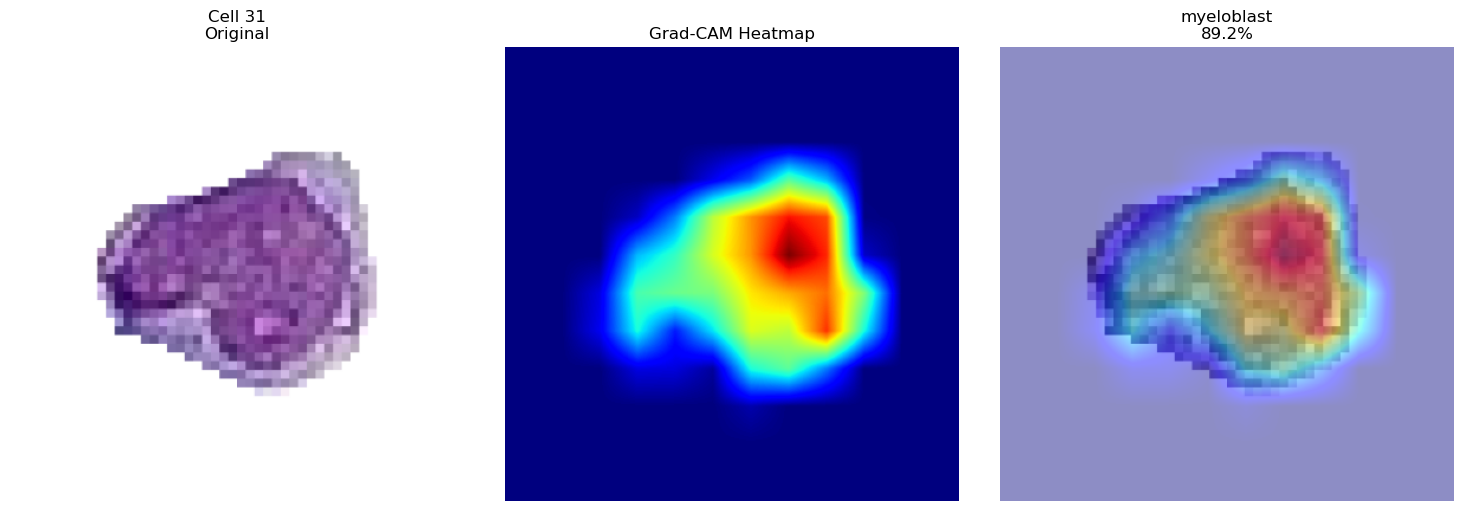

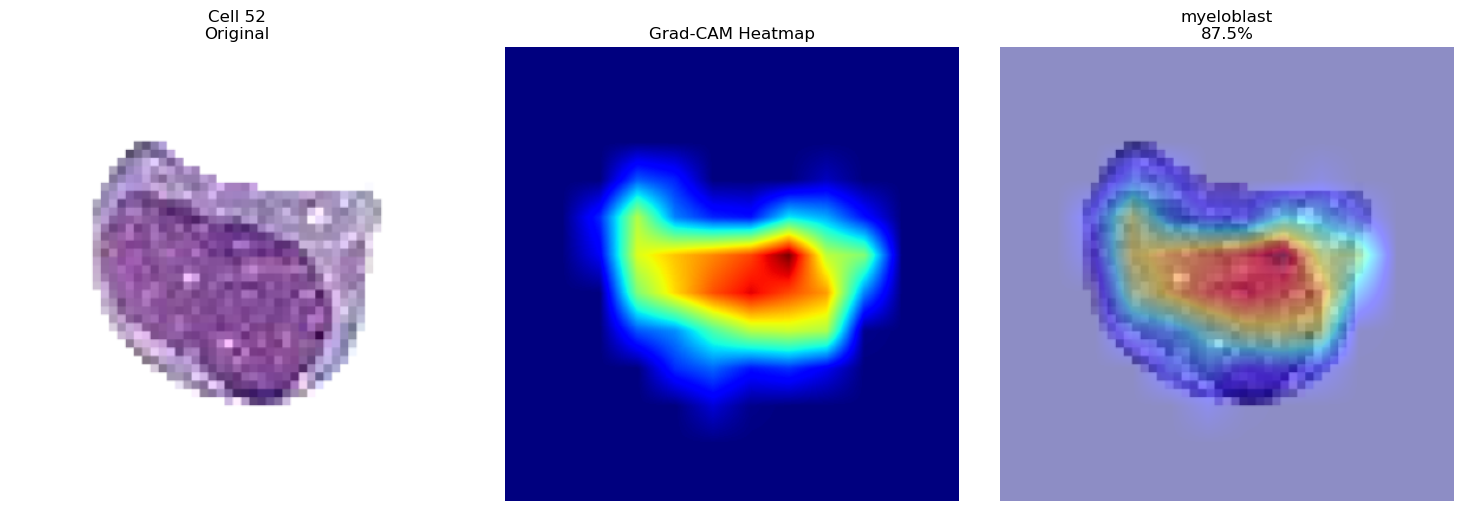

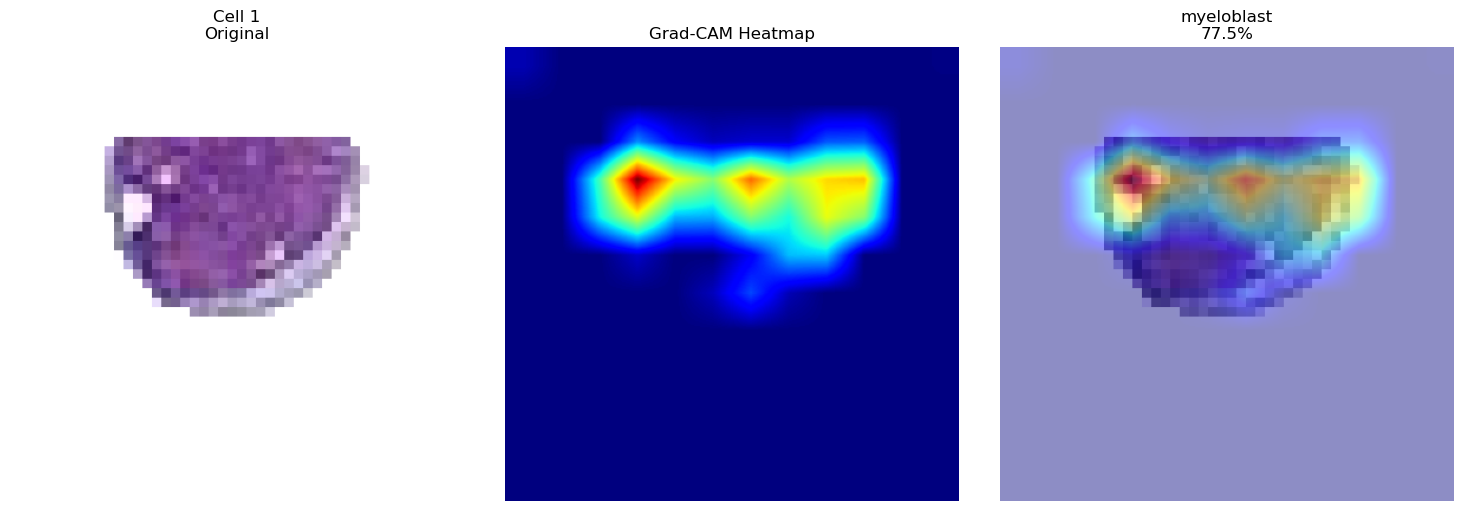


Grad-CAM generation complete.
Saved: 6 images


In [56]:
# ============================================
# GENERATE GRAD-CAM FOR SELECTED CELLS
# ============================================

XAI_DIR = "../images/xai_results"
os.makedirs(XAI_DIR, exist_ok=True)

gradcam_records = []

# Use up to 6 highest-confidence candidates
xai_cells = myeloblast_df.head(6)

print(
    "Generating Grad-CAM for cells:",
    xai_cells["cell_id"].tolist()
)

for _, row in xai_cells.iterrows():

    cell_id = int(row["cell_id"])

    idx = cell_df.index[
        cell_df["cell_id"] == cell_id
    ][0]

    # 384 × 384 image
    image = X[idx].copy()

    # ResNet50 preprocessing
    image_input = preprocess_input(
        image.astype(np.float32)
    )

    image_input = np.expand_dims(
        image_input,
        axis=0
    )

    class_index = int(
        np.argmax(predictions[idx])
    )

    class_name = CLASS_NAMES[class_index]
    confidence = predictions[idx][class_index]

    # Grad-CAM
    heatmap = generate_gradcam(
        image_input,
        class_index
    )

    heatmap_resized = cv2.resize(
        heatmap,
        (384, 384),
        interpolation=cv2.INTER_LINEAR
    )

    original_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Create figure
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(original_rgb)
    axes[0].set_title(
        f"Cell {cell_id}\n"
        f"Original"
    )
    axes[0].axis("off")

    axes[1].imshow(
        heatmap_resized,
        cmap="jet"
    )
    axes[1].set_title(
        "Grad-CAM Heatmap"
    )
    axes[1].axis("off")

    axes[2].imshow(original_rgb)
    axes[2].imshow(
        heatmap_resized,
        cmap="jet",
        alpha=0.45
    )
    axes[2].set_title(
        f"{class_name}\n"
        f"{confidence*100:.1f}%"
    )
    axes[2].axis("off")

    plt.tight_layout()

    save_path = os.path.join(
        XAI_DIR,
        f"cell_{cell_id}_gradcam.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    gradcam_records.append({
        "cell_id": cell_id,
        "class": class_name,
        "confidence": float(confidence),
        "path": save_path
    })

print("\nGrad-CAM generation complete.")
print("Saved:", len(gradcam_records), "images")

In [57]:
# ============================================
# FINAL SUMMARY
# ============================================

total_objects = len(cell_df)
candidate_count = len(candidate_df)
myeloblast_count = len(myeloblast_df)

print("=" * 55)
print("WHOLE-SMEAR ANALYSIS")
print("=" * 55)

print(f"Cellpose objects:              {total_objects}")
print(f"Nucleated-cell candidates:    {candidate_count}")
print(f"Myeloblast-like candidates:   {myeloblast_count}")

if candidate_count > 0:
    proportion = (
        myeloblast_count /
        candidate_count *
        100
    )

    print(
        f"Myeloblast-like proportion:   "
        f"{proportion:.2f}%"
    )

print("=" * 55)

print(
    "\nNOTE: This is a research screening result."
)
print(
    "It must NOT be interpreted as an AML diagnosis."
)

WHOLE-SMEAR ANALYSIS
Cellpose objects:              83
Nucleated-cell candidates:    16
Myeloblast-like candidates:   9
Myeloblast-like proportion:   56.25%

NOTE: This is a research screening result.
It must NOT be interpreted as an AML diagnosis.


In [58]:
# ============================================
# SHAP SETUP
# ============================================

import shap

print("SHAP version:", shap.__version__)

# Select one of the same cells used for Grad-CAM
shap_row = xai_cells.iloc[0]

shap_cell_id = int(shap_row["cell_id"])

shap_idx = cell_df.index[
    cell_df["cell_id"] == shap_cell_id
][0]

print("SHAP test cell:", shap_cell_id)
print(
    "Predicted class:",
    cell_df.loc[shap_idx, "predicted_class"]
)
print(
    "Confidence:",
    f"{cell_df.loc[shap_idx, 'confidence']*100:.2f}%"
)

SHAP version: 0.52.0
SHAP test cell: 65
Predicted class: myeloblast
Confidence: 93.28%


In [59]:
# ============================================
# SHAP EXPLAINER
# ============================================

background = X_preprocessed[:10]

explainer = shap.GradientExplainer(
    model,
    background
)

print("SHAP GradientExplainer created.")

SHAP GradientExplainer created.


In [60]:
# ============================================
# SHAP — ONE CELL
# ============================================

shap_input = X_preprocessed[
    shap_idx:shap_idx + 1
]

shap_values = explainer.shap_values(
    shap_input
)

print(
    "SHAP explanation generated."
)

print(
    "Number of outputs:",
    len(shap_values)
)

/home/sahil/miniconda3/envs/ds/lib/python3.13/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(1, 384, 384, 3))']
  warnings.warn(msg)
/home/sahil/miniconda3/envs/ds/lib/python3.13/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(50, 384, 384, 3))']
  warnings.warn(msg)


SHAP explanation generated.
Number of outputs: 1


In [63]:
# ============================================
# CORRECT SHAP VISUALIZATION
# ============================================

predicted_index = int(
    np.argmax(predictions[shap_idx])
)

predicted_class = CLASS_NAMES[predicted_index]

print("Cell:", shap_cell_id)
print("Predicted class:", predicted_class)
print(
    "Confidence:",
    f"{predictions[shap_idx][predicted_index] * 100:.2f}%"
)

# SHAP shape:
# (1, 384, 384, 3, 5)

# Select:
# image 0
# all height
# all width
# all RGB channels
# predicted class
values = shap_values[
    0, :, :, :, predicted_index
]

print("Selected SHAP shape:", values.shape)

Cell: 65
Predicted class: myeloblast
Confidence: 93.28%
Selected SHAP shape: (384, 384, 3)


In [64]:
# ============================================
# SHAP MAGNITUDE MAP
# ============================================

# Combine RGB channel contributions
shap_magnitude = np.mean(
    np.abs(values),
    axis=-1
)

print(
    "SHAP magnitude min:",
    shap_magnitude.min()
)

print(
    "SHAP magnitude max:",
    shap_magnitude.max()
)

print(
    "SHAP magnitude mean:",
    shap_magnitude.mean()
)

# Use percentile normalization so the
# relatively small SHAP values are visible
low = np.percentile(
    shap_magnitude,
    1
)

high = np.percentile(
    shap_magnitude,
    99
)

shap_display = np.clip(
    (shap_magnitude - low) /
    (high - low + 1e-8),
    0,
    1
)

SHAP magnitude min: 0.0
SHAP magnitude max: 0.010542472979674736
SHAP magnitude mean: 0.00017445007805988897


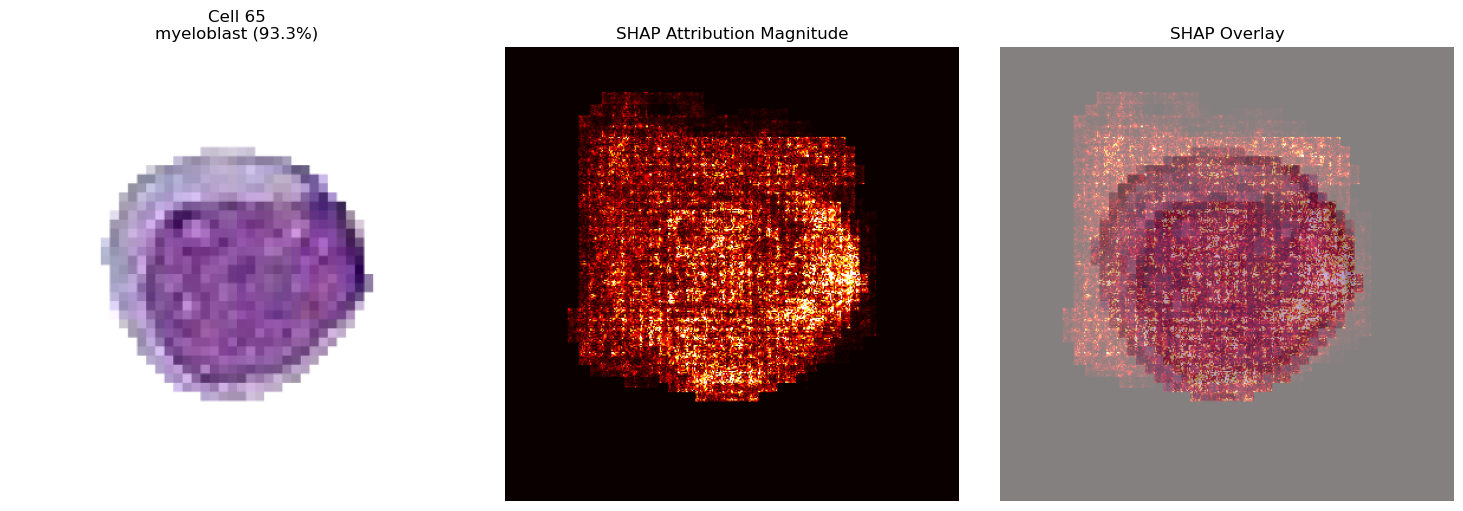

In [65]:
# ============================================
# SHAP ORIGINAL + HEATMAP + OVERLAY
# ============================================

display_image = cv2.cvtColor(
    X[shap_idx],
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)

plt.imshow(display_image)

plt.title(
    f"Cell {shap_cell_id}\n"
    f"{predicted_class} "
    f"({predictions[shap_idx][predicted_index]*100:.1f}%)"
)

plt.axis("off")


# SHAP heatmap
plt.subplot(1, 3, 2)

plt.imshow(
    shap_display,
    cmap="hot"
)

plt.title(
    "SHAP Attribution Magnitude"
)

plt.axis("off")


# Overlay
plt.subplot(1, 3, 3)

plt.imshow(display_image)

plt.imshow(
    shap_display,
    cmap="hot",
    alpha=0.5
)

plt.title(
    "SHAP Overlay"
)

plt.axis("off")

plt.tight_layout()
plt.show()

In [62]:
print("Type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of outputs:", len(shap_values))
    for i, v in enumerate(shap_values):
        print(
            i,
            "shape:", np.asarray(v).shape,
            "min:", np.min(v),
            "max:", np.max(v),
            "mean abs:", np.mean(np.abs(v))
        )
else:
    print(
        "Shape:",
        np.asarray(shap_values).shape
    )
    print(
        "Min:",
        np.min(shap_values)
    )
    print(
        "Max:",
        np.max(shap_values)
    )
    print(
        "Mean abs:",
        np.mean(np.abs(shap_values))
    )

Type: <class 'numpy.ndarray'>
Shape: (1, 384, 384, 3, 5)
Min: -0.04187964275479317
Max: 0.03498433157801628
Mean abs: 0.0001494350070485377


Processing Cell 65 (myeloblast, 93.3%)


/home/sahil/miniconda3/envs/ds/lib/python3.13/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(1, 384, 384, 3))']
  warnings.warn(msg)


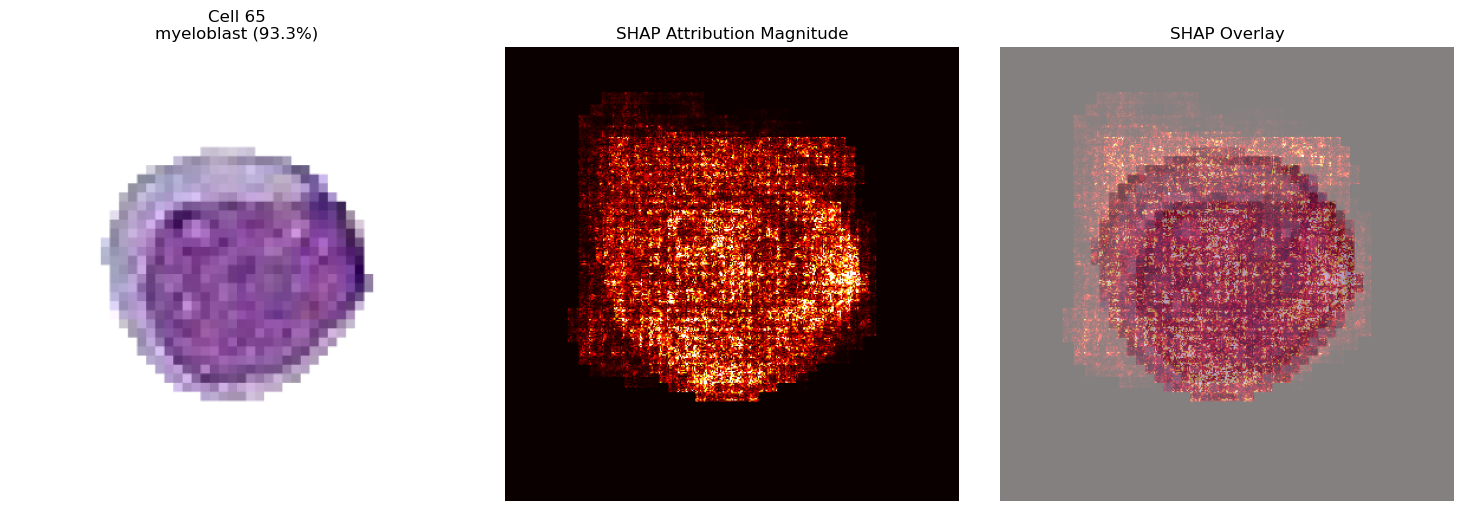

Processing Cell 33 (myeloblast, 90.5%)


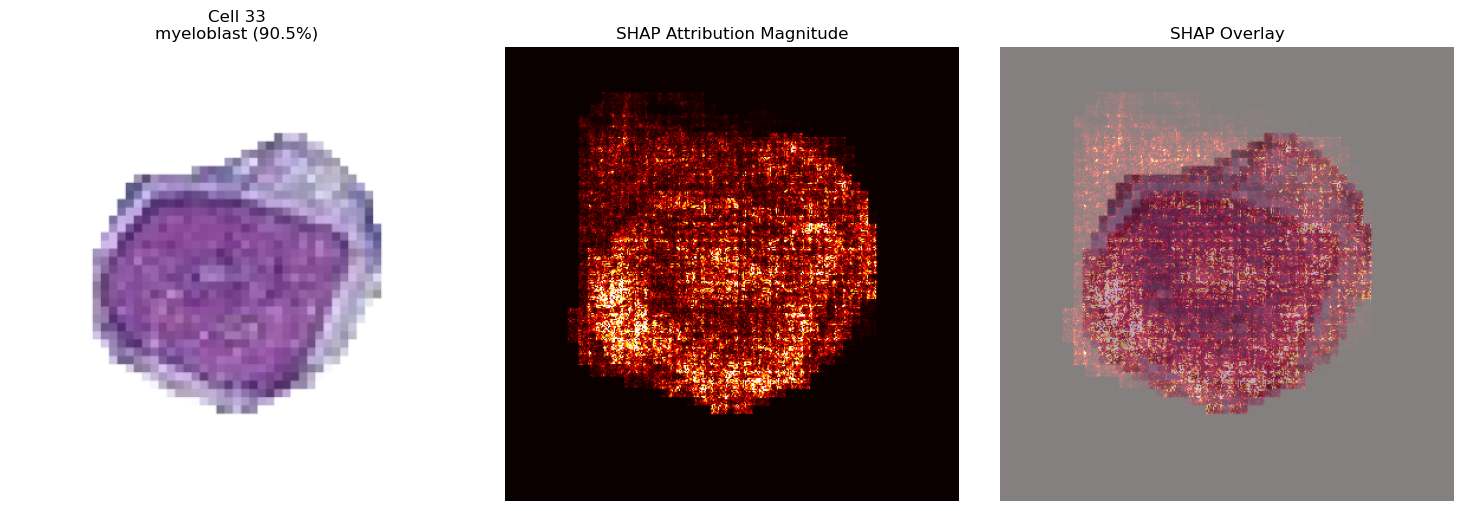

Processing Cell 4 (myeloblast, 90.4%)


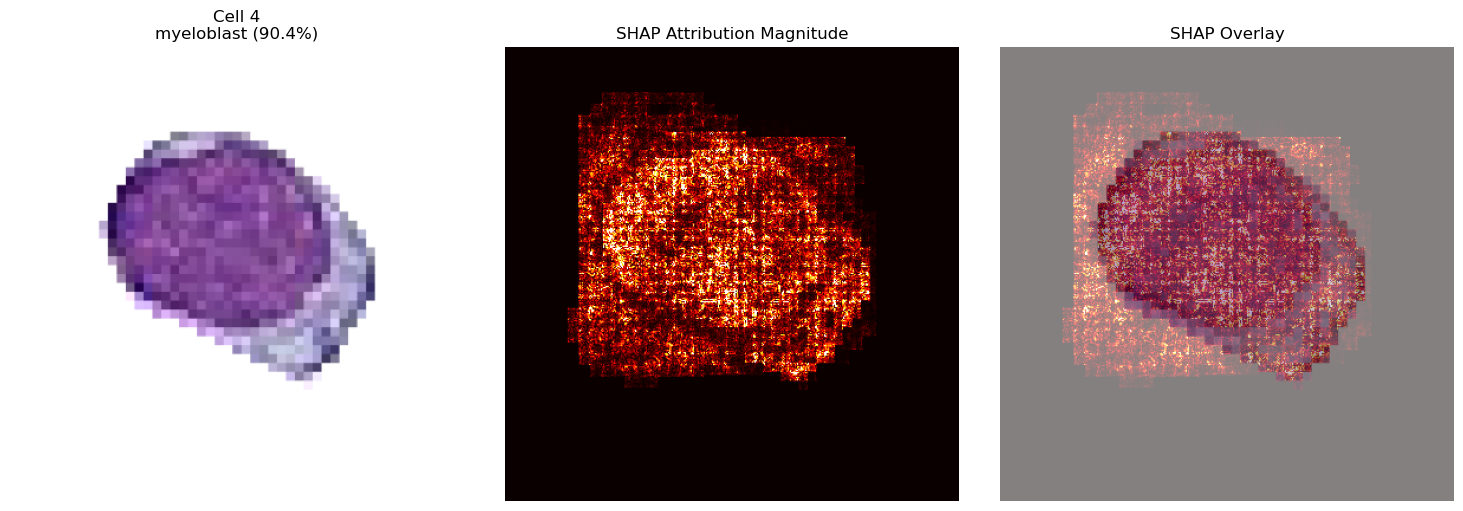

Processing Cell 31 (myeloblast, 89.2%)


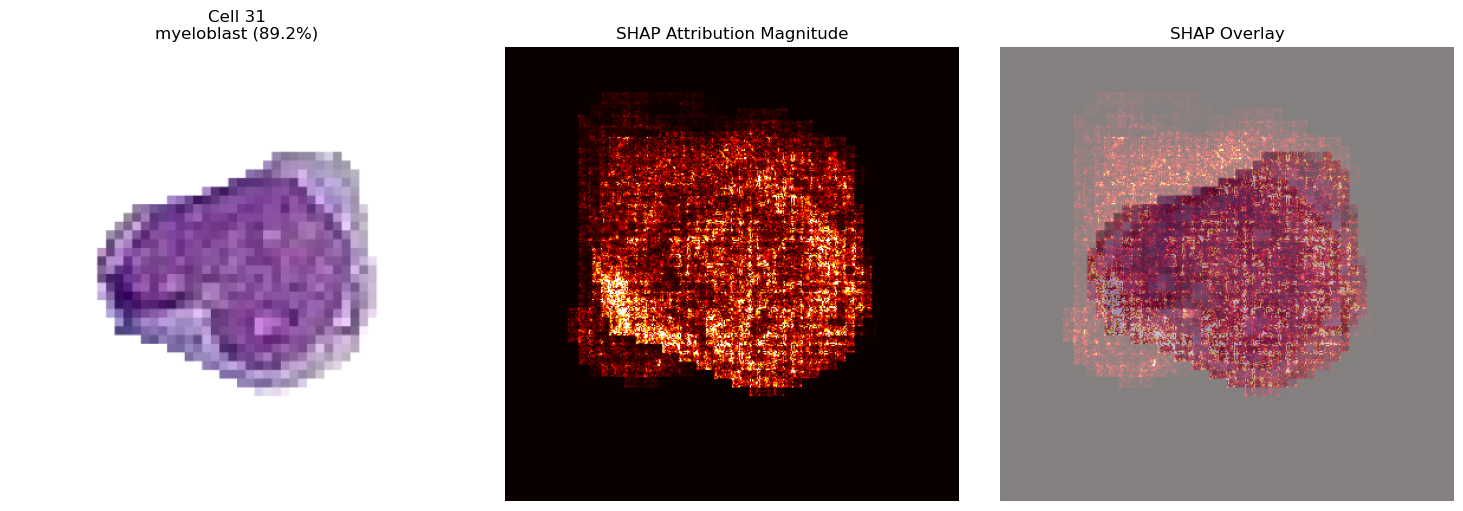

Processing Cell 52 (myeloblast, 87.5%)


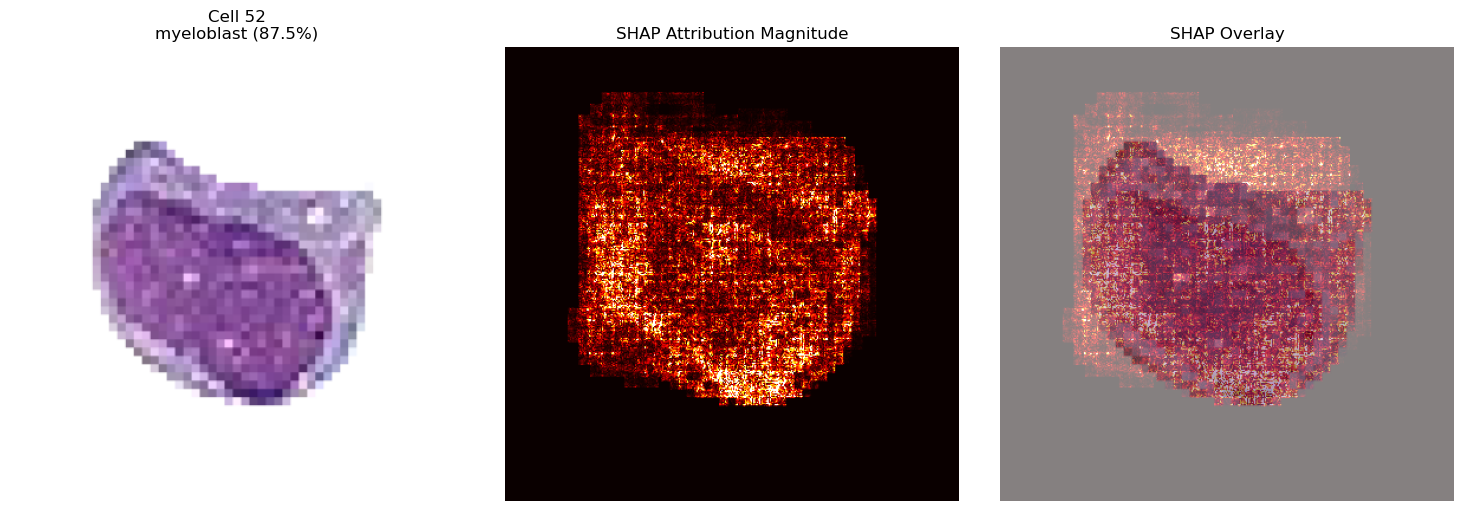

Processing Cell 1 (myeloblast, 77.5%)


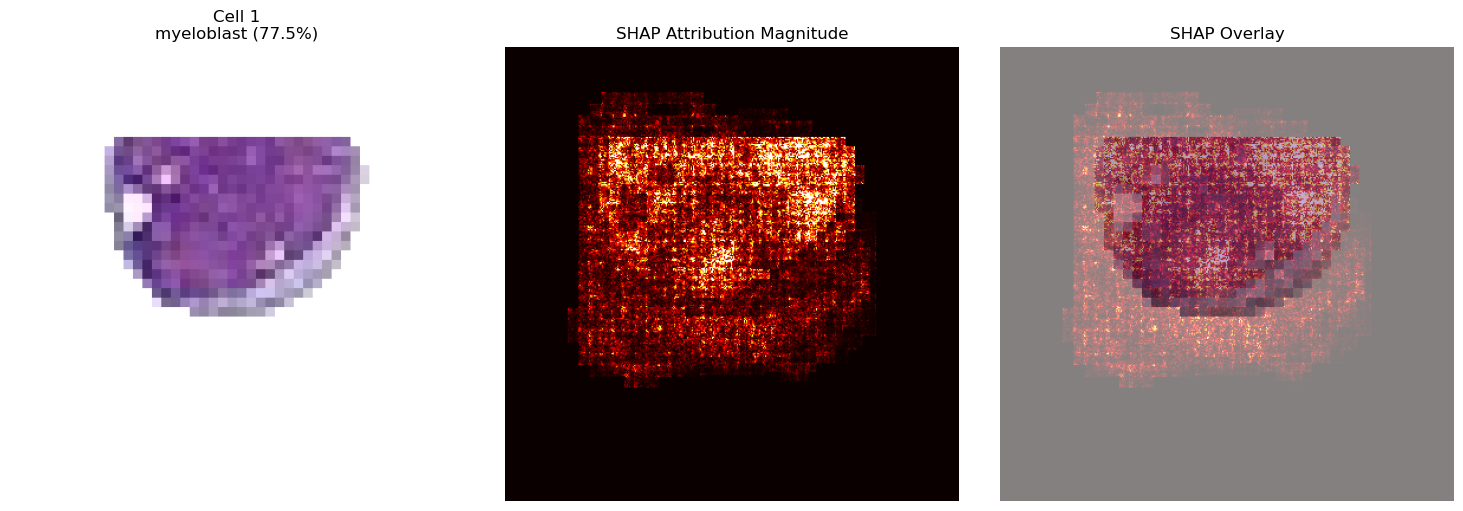


SHAP generation complete.
Saved: 6 SHAP images


In [66]:
# ============================================
# GENERATE SHAP FOR SELECTED CELLS
# ============================================

shap_records = []

for _, row in xai_cells.iterrows():

    cell_id = int(row["cell_id"])

    idx = cell_df.index[
        cell_df["cell_id"] == cell_id
    ][0]

    image_input = X_preprocessed[
        idx:idx + 1
    ]

    predicted_index = int(
        np.argmax(predictions[idx])
    )

    predicted_class = CLASS_NAMES[
        predicted_index
    ]

    confidence = predictions[
        idx,
        predicted_index
    ]

    print(
        f"Processing Cell {cell_id} "
        f"({predicted_class}, "
        f"{confidence*100:.1f}%)"
    )

    # SHAP
    values_all = explainer.shap_values(
        image_input
    )

    # Current SHAP format:
    # (1, 384, 384, 3, 5)
    values = values_all[
        0, :, :, :, predicted_index
    ]

    # Combine RGB channels
    shap_magnitude = np.mean(
        np.abs(values),
        axis=-1
    )

    # Percentile normalization
    low = np.percentile(
        shap_magnitude,
        1
    )

    high = np.percentile(
        shap_magnitude,
        99
    )

    shap_display = np.clip(
        (shap_magnitude - low) /
        (high - low + 1e-8),
        0,
        1
    )

    # Original image
    original_rgb = cv2.cvtColor(
        X[idx],
        cv2.COLOR_BGR2RGB
    )

    # Save figure
    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 5)
    )

    axes[0].imshow(original_rgb)
    axes[0].set_title(
        f"Cell {cell_id}\n"
        f"{predicted_class} "
        f"({confidence*100:.1f}%)"
    )
    axes[0].axis("off")

    axes[1].imshow(
        shap_display,
        cmap="hot"
    )
    axes[1].set_title(
        "SHAP Attribution Magnitude"
    )
    axes[1].axis("off")

    axes[2].imshow(original_rgb)
    axes[2].imshow(
        shap_display,
        cmap="hot",
        alpha=0.5
    )
    axes[2].set_title(
        "SHAP Overlay"
    )
    axes[2].axis("off")

    plt.tight_layout()

    save_path = os.path.join(
        XAI_DIR,
        f"cell_{cell_id}_shap.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    shap_records.append({
        "cell_id": cell_id,
        "class": predicted_class,
        "confidence": float(confidence),
        "path": save_path
    })

print("\nSHAP generation complete.")
print("Saved:", len(shap_records), "SHAP images")

In [67]:
# ============================================
# SAVE SHAP RECORDS
# ============================================

shap_df = pd.DataFrame(shap_records)

shap_csv_path = os.path.join(
    XAI_DIR,
    "shap_results.csv"
)

shap_df.to_csv(
    shap_csv_path,
    index=False
)

print("SHAP results saved:")
print(shap_csv_path)

SHAP results saved:
../images/xai_results/shap_results.csv


In [68]:
# ============================================
# FINAL CELL ANALYSIS TABLE
# ============================================

final_table = candidate_df[
    [
        "cell_id",
        "area",
        "purple_score",
        "predicted_class",
        "confidence"
    ]
].copy()

final_table["confidence_percent"] = (
    final_table["confidence"] * 100
).round(2)

final_table = final_table.drop(
    columns=["confidence"]
)

final_table = final_table.sort_values(
    "cell_id"
)

print(final_table.to_string(index=False))

 cell_id  area  purple_score predicted_class  confidence_percent
       1   446     53.456619      myeloblast           77.500000
       3   401     57.119347        basophil           97.480003
       4   598     52.029362      myeloblast           90.379997
      12   899     47.025597        basophil           82.209999
      21   607     42.339138        basophil           98.169998
      28   697     49.134338      myeloblast           69.300003
      30   149     60.177853    erythroblast           87.730003
      31   647     52.833591      myeloblast           89.190002
      32   500     51.493965        basophil           55.459999
      33   895     47.401234      myeloblast           90.470001
      43   795     49.247482        basophil           91.000000
      52   822     48.797546      myeloblast           87.529999
      64   989     43.818737        basophil           98.949997
      65   631     50.246033      myeloblast           93.279999
      79   658     49.210

In [69]:
# ============================================
# SCREENING SUMMARY
# ============================================

total_segmented = len(cell_df)
candidate_count = len(candidate_df)
myeloblast_count = len(myeloblast_df)

if candidate_count > 0:
    myeloblast_proportion = (
        myeloblast_count /
        candidate_count *
        100
    )
else:
    myeloblast_proportion = 0

print("=" * 60)
print("FINAL SCREENING SUMMARY")
print("=" * 60)

print(
    f"Total Cellpose objects: "
    f"{total_segmented}"
)

print(
    f"Nucleated-cell candidates: "
    f"{candidate_count}"
)

print(
    f"Myeloblast-like candidates: "
    f"{myeloblast_count}"
)

print(
    f"Myeloblast-like proportion: "
    f"{myeloblast_proportion:.2f}%"
)

print("=" * 60)

FINAL SCREENING SUMMARY
Total Cellpose objects: 83
Nucleated-cell candidates: 16
Myeloblast-like candidates: 9
Myeloblast-like proportion: 56.25%


In [70]:
# ============================================
# SAVE ORIGINAL SMEAR
# ============================================

original_smear_path = os.path.join(
    XAI_DIR,
    "original_smear.png"
)

cv2.imwrite(
    original_smear_path,
    smear_bgr
)

print(
    "Original smear saved:",
    original_smear_path
)

Original smear saved: ../images/xai_results/original_smear.png


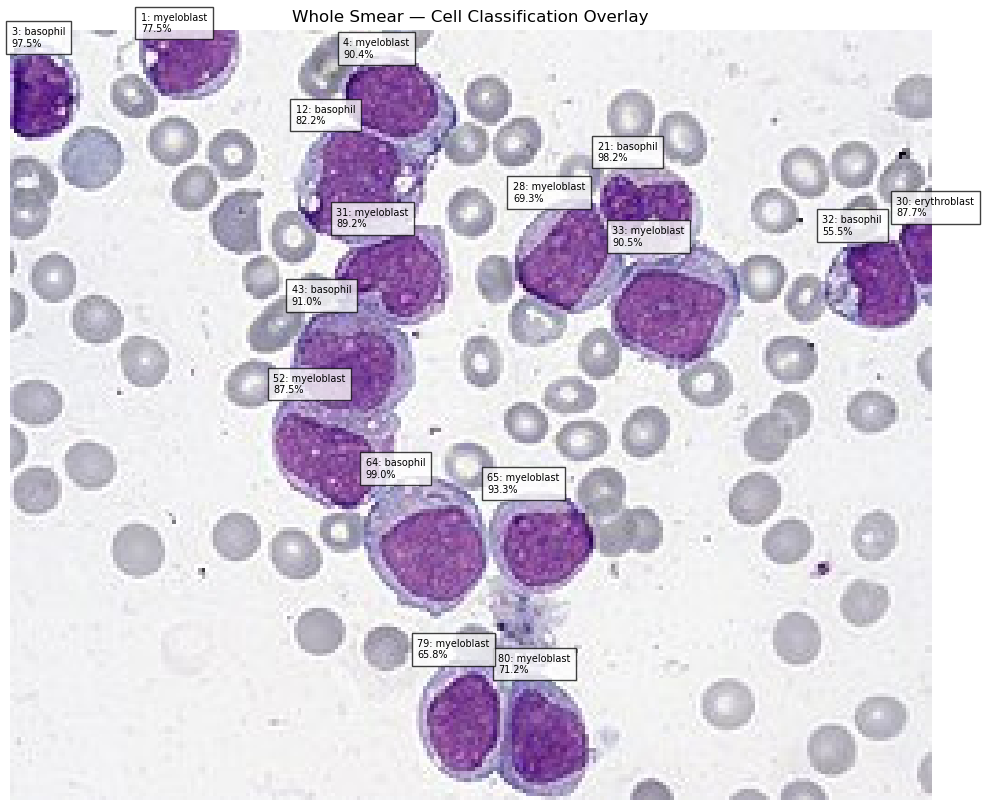

Overlay saved: ../images/xai_results/classification_overlay.png


In [71]:
# ============================================
# SAVE SEGMENTATION + CLASSIFICATION OVERLAY
# ============================================

overlay_rgb = cv2.cvtColor(
    smear_bgr,
    cv2.COLOR_BGR2RGB
).copy()

plt.figure(figsize=(14, 10))

plt.imshow(overlay_rgb)

for _, row in candidate_df.iterrows():

    x = int(row["x"])
    y = int(row["y"])

    cell_id = int(row["cell_id"])

    label = row["predicted_class"]

    confidence = (
        row["confidence"] * 100
    )

    plt.text(
        x,
        y,
        f"{cell_id}: {label}\n"
        f"{confidence:.1f}%",
        fontsize=7,
        bbox=dict(
            facecolor="white",
            alpha=0.75
        )
    )

plt.axis("off")

plt.title(
    "Whole Smear — Cell Classification Overlay"
)

overlay_path = os.path.join(
    XAI_DIR,
    "classification_overlay.png"
)

plt.savefig(
    overlay_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(
    "Overlay saved:",
    overlay_path
)

In [75]:
# ============================================================
# CELL 46 — ADVANCED VLM + XAI EXPLANATORY REPORT
# ============================================================
#
# DO NOT RERUN PREVIOUS CELLS.
#
# This cell uses the results already generated by Cells 17–45:
#   model
#   predictions
#   cell_df
#   candidate_df
#   myeloblast_df
#   xai_cells
#   gradcam_records
#   shap_records
#   original_smear_path
#   overlay_path
#   X
#
# The Hugging Face VLM is used as an explanation/report-writing
# layer. It does NOT replace ResNet50 and does NOT diagnose cancer.
#
# If Hugging Face is unavailable, the report automatically creates
# detailed evidence-based explanations instead of saying
# "VLM unavailable".
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import re
import sys
import base64
import subprocess
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.styles import (
    getSampleStyleSheet,
    ParagraphStyle
)
from reportlab.lib.units import mm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image as RLImage,
    Table,
    TableStyle,
    PageBreak,
    KeepTogether
)


# ============================================================
# 2. BASIC VALIDATION
# ============================================================

required_variables = [
    "model",
    "predictions",
    "cell_df",
    "candidate_df",
    "myeloblast_df",
    "xai_cells",
    "X",
    "original_smear_path",
    "overlay_path"
]

missing_variables = [
    v for v in required_variables
    if v not in globals()
]

if missing_variables:

    raise RuntimeError(
        "The following variables are missing:\n"
        + ", ".join(missing_variables)
        + "\n\n"
        "This usually means an earlier cell was not executed."
    )

print("Existing Phase 7 results detected successfully.")


# ============================================================
# 3. OUTPUT DIRECTORY
# ============================================================

XAI_DIR = Path(
    globals().get(
        "XAI_DIR",
        "../images/xai_results"
    )
)

XAI_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory:", XAI_DIR.resolve())


# ============================================================
# 4. NORMALIZE CONFIDENCE VALUES
# ============================================================

def confidence_percent(value):
    """
    Converts stored confidence to percentage.

    Your notebook stores probabilities between 0 and 1.
    Example:
        0.933 -> 93.3%
    """

    value = float(value)

    if value <= 1.0:
        return value * 100.0

    return value


# ============================================================
# 5. BUILD DETAILED CELL RESULTS
# ============================================================

CLASS_NAMES_REPORT = [
    "basophil",
    "erythroblast",
    "monocyte",
    "myeloblast",
    "seg_neutrophil"
]


detailed_cells = []

for _, row in xai_cells.iterrows():

    cell_id = int(row["cell_id"])

    # Locate original index
    matches = cell_df.index[
        cell_df["cell_id"] == cell_id
    ]

    if len(matches) == 0:
        continue

    idx = matches[0]

    probs = np.asarray(
        predictions[idx]
    ).astype(float)

    sorted_indices = np.argsort(
        probs
    )[::-1]

    top_index = int(
        sorted_indices[0]
    )

    second_index = int(
        sorted_indices[1]
    )

    predicted_class = CLASS_NAMES_REPORT[
        top_index
    ]

    confidence = float(
        probs[top_index]
    )

    second_class = CLASS_NAMES_REPORT[
        second_index
    ]

    second_confidence = float(
        probs[second_index]
    )

    margin = (
        confidence -
        second_confidence
    )

    # Cell properties
    area = float(
        row.get(
            "area",
            cell_df.loc[idx, "area"]
        )
    )

    purple_score = float(
        row.get(
            "purple_score",
            cell_df.loc[idx, "purple_score"]
        )
    )

    detailed_cells.append({

        "cell_id": cell_id,

        "index": idx,

        "predicted_class": predicted_class,

        "confidence": confidence,

        "confidence_percent":
            confidence_percent(confidence),

        "second_class":
            second_class,

        "second_confidence":
            second_confidence,

        "second_confidence_percent":
            confidence_percent(second_confidence),

        "margin":
            margin,

        "margin_percent":
            confidence_percent(margin),

        "area":
            area,

        "purple_score":
            purple_score,

        "probabilities":
            probs

    })


# Sort by confidence
detailed_cells = sorted(
    detailed_cells,
    key=lambda x: x["confidence"],
    reverse=True
)

print()
print("Detailed cell analysis:")
print()

for c in detailed_cells:

    print(
        f"Cell {c['cell_id']:>3} | "
        f"{c['predicted_class']:<15} | "
        f"{c['confidence_percent']:>6.2f}% | "
        f"2nd: {c['second_class']:<15} "
        f"{c['second_confidence_percent']:>6.2f}% | "
        f"Margin: {c['margin_percent']:>6.2f}%"
    )


# ============================================================
# 6. FIND GRAD-CAM / SHAP FILES
# ============================================================

def extract_cell_id_from_filename(path):

    match = re.search(
        r"cell[_-](\d+)",
        Path(path).name.lower()
    )

    if match:
        return int(match.group(1))

    return None


gradcam_map = {}

for p in XAI_DIR.glob("*gradcam*.png"):

    cid = extract_cell_id_from_filename(p)

    if cid is not None:
        gradcam_map[cid] = Path(p)


shap_map = {}

for p in XAI_DIR.glob("*shap*.png"):

    cid = extract_cell_id_from_filename(p)

    if cid is not None:
        shap_map[cid] = Path(p)


print()
print("Grad-CAM files:", len(gradcam_map))
print("SHAP files:", len(shap_map))


# ============================================================
# 7. SAVE ORIGINAL CELL IMAGES
# ============================================================

def save_original_cell(cell_info):

    cell_id = cell_info["cell_id"]
    idx = cell_info["index"]

    crop_bgr = np.asarray(
        X[idx]
    ).astype(np.uint8)

    crop_rgb = cv2.cvtColor(
        crop_bgr,
        cv2.COLOR_BGR2RGB
    )

    path = XAI_DIR / (
        f"cell_{cell_id}_original_for_report.png"
    )

    Image.fromarray(
        crop_rgb
    ).save(path)

    return path


for c in detailed_cells:

    c["original_path"] = (
        save_original_cell(c)
    )

    c["gradcam_path"] = (
        gradcam_map.get(
            c["cell_id"]
        )
    )

    c["shap_path"] = (
        shap_map.get(
            c["cell_id"]
        )
    )


# ============================================================
# 8. CREATE A CELL EVIDENCE PANEL
# ============================================================

def create_evidence_panel(cell_info):

    cell_id = cell_info["cell_id"]

    original_path = cell_info[
        "original_path"
    ]

    gradcam_path = cell_info[
        "gradcam_path"
    ]

    shap_path = cell_info[
        "shap_path"
    ]

    # White canvas
    canvas = Image.new(
        "RGB",
        (1800, 700),
        "white"
    )

    draw = ImageDraw.Draw(
        canvas
    )

    try:
        font_large = ImageFont.truetype(
            "DejaVuSans-Bold.ttf",
            32
        )

        font_small = ImageFont.truetype(
            "DejaVuSans.ttf",
            22
        )

    except Exception:

        font_large = None
        font_small = None


    images = [
        (
            "ORIGINAL CELL",
            original_path
        ),
        (
            "GRAD-CAM",
            gradcam_path
        ),
        (
            "SHAP",
            shap_path
        )
    ]


    positions = [
        0,
        600,
        1200
    ]


    for label, path, x_position in zip(
        [x[0] for x in images],
        [x[1] for x in images],
        positions
    ):

        draw.text(
            (x_position + 15, 10),
            label,
            fill="black",
            font=font_large
        )

        if path is None:
            continue

        path = Path(path)

        if not path.exists():
            continue

        try:

            img = Image.open(
                path
            ).convert("RGB")

            # Resize maintaining aspect ratio
            img.thumbnail(
                (560, 600)
            )

            y_position = 65

            canvas.paste(
                img,
                (
                    x_position +
                    (560 - img.width) // 2,
                    y_position
                )
            )

        except Exception as e:

            print(
                f"Could not add {path}: {e}"
            )


    output_path = XAI_DIR / (
        f"cell_{cell_id}_evidence_panel.png"
    )

    canvas.save(
        output_path
    )

    return output_path


for c in detailed_cells:

    c["evidence_panel"] = (
        create_evidence_panel(c)
    )


# ============================================================
# 9. HUGGING FACE SETUP
# ============================================================

HF_AVAILABLE = False
HF_ERROR = None
client = None

try:

    from huggingface_hub import (
        InferenceClient
    )

    HF_AVAILABLE = True

except Exception:

    print(
        "Installing huggingface_hub..."
    )

    try:

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "-U",
            "huggingface_hub"
        ])

        from huggingface_hub import (
            InferenceClient
        )

        HF_AVAILABLE = True

    except Exception as e:

        HF_ERROR = str(e)
        HF_AVAILABLE = False


# ============================================================
# 10. HUGGING FACE TOKEN
# ============================================================

HF_TOKEN = os.environ.get(
    "HF_TOKEN",
    None
)

if HF_AVAILABLE:

    if HF_TOKEN is None:

        print()
        print(
            "Hugging Face token is needed "
            "for the VLM explanation."
        )
        print(
            "If you already authenticated with "
            "Hugging Face, just press Enter."
        )
        print()

        try:

            HF_TOKEN = getpass(
                "HF token (input hidden): "
            ).strip()

        except Exception:

            HF_TOKEN = ""

    if HF_TOKEN == "":
        HF_TOKEN = None


# ============================================================
# 11. INITIALIZE VLM
# ============================================================

MODEL_ID = (
    "Qwen/Qwen2.5-VL-3B-Instruct"
)

if HF_AVAILABLE:

    try:

        client = InferenceClient(
            model=MODEL_ID,
            token=HF_TOKEN
        )

        print()
        print(
            "Vision-language model:",
            MODEL_ID
        )

    except Exception as e:

        HF_AVAILABLE = False
        HF_ERROR = str(e)


# ============================================================
# 12. IMAGE -> DATA URL
# ============================================================

def image_to_data_url(path):

    path = Path(path)

    with open(
        path,
        "rb"
    ) as f:

        encoded = base64.b64encode(
            f.read()
        ).decode("utf-8")

    extension = (
        path.suffix.lower()
    )

    if extension in [
        ".jpg",
        ".jpeg"
    ]:

        mime = "image/jpeg"

    elif extension == ".webp":

        mime = "image/webp"

    else:

        mime = "image/png"

    return (
        f"data:{mime};base64,{encoded}"
    )


# ============================================================
# 13. ASK QWEN FOR CELL EXPLANATION
# ============================================================

def ask_vlm_for_cell(cell_info):

    if not HF_AVAILABLE or client is None:

        return None


    cell_id = cell_info[
        "cell_id"
    ]

    predicted_class = cell_info[
        "predicted_class"
    ]

    confidence = cell_info[
        "confidence_percent"
    ]

    second_class = cell_info[
        "second_class"
    ]

    second_confidence = cell_info[
        "second_confidence_percent"
    ]

    margin = cell_info[
        "margin_percent"
    ]

    area = cell_info[
        "area"
    ]

    purple_score = cell_info[
        "purple_score"
    ]

    panel = cell_info[
        "evidence_panel"
    ]


    prompt = f"""
You are writing a scientific computer-vision analysis report.

Analyze the supplied evidence panel for Cell {cell_id}.

The ResNet50 model produced:

Predicted class:
{predicted_class}

Model confidence:
{confidence:.2f}%

Second-best class:
{second_class}

Second-best probability:
{second_confidence:.2f}%

Prediction margin:
{margin:.2f} percentage points

Cell segmentation area:
{area:.0f} pixels

Purple-score:
{purple_score:.2f}

The evidence panel contains:
1. Original segmented cell
2. Grad-CAM result
3. SHAP result

Write a detailed but scientifically cautious explanation with EXACTLY
these headings:

MODEL DECISION
XAI EVIDENCE
CROSS-METHOD CONSISTENCY
RELIABILITY INTERPRETATION
SCIENTIFIC LIMITATION

Under MODEL DECISION:
Explain what the classifier selected and how strongly it selected it
relative to the second-best class.

Under XAI EVIDENCE:
Describe where Grad-CAM appears concentrated and what the SHAP
attribution appears to cover.

Under CROSS-METHOD CONSISTENCY:
Discuss whether Grad-CAM and SHAP broadly point toward the same
cellular region or whether they appear different.

Under RELIABILITY INTERPRETATION:
Explain what the confidence and prediction margin mean for model
behavior. Do NOT call confidence a clinical probability.

Under SCIENTIFIC LIMITATION:
Explain that XAI shows model behavior rather than proving a biological
cell identity.

IMPORTANT:
- Do not diagnose cancer.
- Do not diagnose AML.
- Do not say that the patient has leukemia.
- Do not independently override the ResNet50 prediction.
- Do not invent cellular structures.
- Do not claim that a heatmap proves a nucleus, granule, chromatin,
  nucleolus, or any other biological structure unless clearly visible
  and even then describe it cautiously.
- Do not treat model confidence as medical certainty.
- If attribution reaches the boundary/background, explicitly mention
  this as a possible model shortcut or limitation.

Write approximately 250–350 words.
"""

    try:

        content = [
            {
                "type": "image_url",
                "image_url": {
                    "url":
                    image_to_data_url(panel)
                }
            },
            {
                "type": "text",
                "text": prompt
            }
        ]


        response = (
            client.chat.completions.create(
                model=MODEL_ID,
                messages=[
                    {
                        "role": "system",
                        "content":
                        (
                            "You are a scientific "
                            "medical-imaging report writer. "
                            "You explain machine-learning "
                            "evidence and do not make "
                            "medical diagnoses."
                        )
                    },
                    {
                        "role": "user",
                        "content": content
                    }
                ],
                max_tokens=700,
                temperature=0.2
            )
        )


        return (
            response
            .choices[0]
            .message
            .content
            .strip()
        )

    except Exception as e:

        print(
            f"VLM failed for Cell {cell_id}:"
        )
        print(e)

        return None


# ============================================================
# 14. DETAILED FALLBACK EXPLANATION
# ============================================================

def fallback_explanation(cell_info):

    cell_id = cell_info[
        "cell_id"
    ]

    predicted_class = cell_info[
        "predicted_class"
    ]

    confidence = cell_info[
        "confidence_percent"
    ]

    second_class = cell_info[
        "second_class"
    ]

    second_confidence = cell_info[
        "second_confidence_percent"
    ]

    margin = cell_info[
        "margin_percent"
    ]

    area = cell_info[
        "area"
    ]

    purple_score = cell_info[
        "purple_score"
    ]

    has_gradcam = (
        cell_info["gradcam_path"]
        is not None
    )

    has_shap = (
        cell_info["shap_path"]
        is not None
    )


    if confidence >= 90:

        strength = (
            "The model selected this class "
            "with a strong softmax preference."
        )

    elif confidence >= 75:

        strength = (
            "The model showed a substantial "
            "preference for this class, although "
            "the prediction is less separated from "
            "alternative classes than a very high-"
            "confidence prediction."
        )

    else:

        strength = (
            "The prediction has comparatively "
            "limited separation and should be "
            "treated cautiously."
        )


    if margin >= 50:

        margin_text = (
            f"The predicted class exceeds the "
            f"second-best class by approximately "
            f"{margin:.1f} percentage points."
        )

    elif margin >= 20:

        margin_text = (
            f"The predicted class has a moderate "
            f"separation of approximately "
            f"{margin:.1f} percentage points from "
            f"the second-best class."
        )

    else:

        margin_text = (
            f"The separation from the second-best "
            f"class is relatively small "
            f"({margin:.1f} percentage points), "
            f"indicating greater model ambiguity."
        )


    explanation = f"""
MODEL DECISION

For Cell {cell_id}, the ResNet50 classifier selected
<b>{predicted_class}</b> with a model confidence of
<b>{confidence:.2f}%</b>. The second-highest class was
<b>{second_class}</b> at <b>{second_confidence:.2f}%</b>.

{strength}

{margin_text}

This describes the model's internal probability distribution.
It should not be interpreted as a clinical probability.


XAI EVIDENCE

Grad-CAM and SHAP were generated specifically for the selected
<b>{predicted_class}</b> output. Grad-CAM provides a spatial
indication of regions contributing to the network's prediction,
while SHAP provides pixel-level attribution magnitude.

The available XAI visualizations should therefore be interpreted
as evidence about which image regions influenced the classifier,
rather than as direct measurements of cell morphology.

The segmentation area for this cell is approximately
<b>{area:.0f} pixels</b>, with a purple-score of approximately
<b>{purple_score:.1f}</b>.


CROSS-METHOD CONSISTENCY

Both Grad-CAM and SHAP are available for this cell.

When the two attribution methods emphasize similar parts of the
segmented cell, this provides stronger evidence that the model is
using internally consistent image regions. When their patterns
differ substantially, the prediction should be interpreted more
cautiously because different explanatory methods may reveal
different aspects of the network's decision.


RELIABILITY INTERPRETATION

The confidence score indicates how strongly the five-class model
preferred the selected class relative to its other available
outputs. It does not measure diagnostic certainty.

This distinction is particularly important when analyzing images
that differ from the training dataset in staining, illumination,
microscope characteristics, cell preparation, or biological
appearance.


SCIENTIFIC LIMITATION

This explanation describes computational model behavior only.
Grad-CAM and SHAP do not establish that the predicted class is
biologically correct, and they do not independently establish the
presence or absence of leukemia or another disease.

The current classifier contains five classes and does not contain
an explicit mature-RBC or unknown-cell category. Consequently,
objects outside the training distribution can still receive a
high-confidence prediction among the available classes.
"""

    return explanation.strip()


# ============================================================
# 15. GENERATE EXPLANATIONS
# ============================================================

print()
print("=" * 70)
print("GENERATING DETAILED CELL EXPLANATIONS")
print("=" * 70)

for number, c in enumerate(
    detailed_cells,
    start=1
):

    print()
    print(
        f"[{number}/{len(detailed_cells)}] "
        f"Cell {c['cell_id']}"
    )

    explanation = (
        ask_vlm_for_cell(c)
    )

    if explanation is None:

        print(
            "Using detailed evidence-based "
            "fallback explanation."
        )

        explanation = (
            fallback_explanation(c)
        )

    else:

        print(
            "VLM explanation generated."
        )

    c["explanation"] = explanation


# ============================================================
# 16. POPULATION-LEVEL ANALYSIS
# ============================================================

total_segmented = len(
    cell_df
)

candidate_count = len(
    candidate_df
)

myeloblast_count = len(
    myeloblast_df
)


if candidate_count > 0:

    myeloblast_proportion = (
        myeloblast_count /
        candidate_count *
        100
    )

else:

    myeloblast_proportion = 0.0


class_counts = (
    candidate_df[
        "predicted_class"
    ]
    .value_counts()
)


class_percentages = (
    candidate_df[
        "predicted_class"
    ]
    .value_counts(
        normalize=True
    ) * 100
)


# Average confidence
if candidate_count > 0:

    average_confidence = (
        candidate_df["confidence"]
        .mean() * 100
    )

else:

    average_confidence = 0.0


# Myeloblast confidence
if myeloblast_count > 0:

    myeloblast_confidences = (
        myeloblast_df["confidence"]
        .values
    )

    myeloblast_mean_conf = (
        myeloblast_confidences.mean()
        * 100
    )

    myeloblast_min_conf = (
        myeloblast_confidences.min()
        * 100
    )

    myeloblast_max_conf = (
        myeloblast_confidences.max()
        * 100
    )

else:

    myeloblast_mean_conf = 0
    myeloblast_min_conf = 0
    myeloblast_max_conf = 0


# ============================================================
# 17. GENERATE POPULATION NARRATIVE
# ============================================================

population_lines = []

population_lines.append(
    f"The segmentation stage identified "
    f"<b>{total_segmented}</b> Cellpose objects."
)

population_lines.append(
    f"After the existing purple-score candidate "
    f"filter, <b>{candidate_count}</b> objects were "
    f"retained for cell-level classification."
)

population_lines.append(
    f"Among these candidates, "
    f"<b>{myeloblast_count}</b> received a "
    f"myeloblast prediction."
)

if candidate_count > 0:

    population_lines.append(
        f"This corresponds to "
        f"<b>{myeloblast_proportion:.2f}%</b> of the "
        f"candidate objects analyzed by this "
        f"particular computational filter."
    )


if myeloblast_count > 0:

    population_lines.append(
        f"The myeloblast predictions had model "
        f"confidence values ranging from "
        f"<b>{myeloblast_min_conf:.1f}%</b> to "
        f"<b>{myeloblast_max_conf:.1f}%</b>, with "
        f"an average of "
        f"<b>{myeloblast_mean_conf:.1f}%</b>."
    )


population_lines.append(
    "These proportions describe the output of the "
    "current segmentation and classification "
    "pipeline. They should not be interpreted as "
    "the percentage of leukemic cells in a patient "
    "or as a cancer probability."
)


population_narrative = (
    " ".join(population_lines)
)


# ============================================================
# 18. CREATE CLASS DISTRIBUTION DATA
# ============================================================

distribution_rows = [
    [
        "Predicted Class",
        "Candidates",
        "Percentage",
        "Mean Confidence"
    ]
]

for class_name in CLASS_NAMES_REPORT:

    count = int(
        class_counts.get(
            class_name,
            0
        )
    )

    percentage = float(
        class_percentages.get(
            class_name,
            0
        )
    )

    subset = candidate_df[
        candidate_df[
            "predicted_class"
        ] == class_name
    ]

    if len(subset) > 0:

        mean_conf = (
            subset["confidence"]
            .mean() * 100
        )

    else:

        mean_conf = 0.0

    distribution_rows.append([
        class_name,
        str(count),
        f"{percentage:.2f}%",
        f"{mean_conf:.2f}%"
    ])


# ============================================================
# 19. PDF STYLES
# ============================================================

styles = getSampleStyleSheet()


title_style = ParagraphStyle(
    "TitleCustom",
    parent=styles["Title"],
    fontName="Helvetica-Bold",
    fontSize=23,
    leading=28,
    alignment=TA_CENTER,
    spaceAfter=15
)


subtitle_style = ParagraphStyle(
    "SubtitleCustom",
    parent=styles["Normal"],
    fontSize=10,
    leading=14,
    alignment=TA_CENTER,
    textColor=colors.grey,
    spaceAfter=18
)


section_style = ParagraphStyle(
    "SectionCustom",
    parent=styles["Heading1"],
    fontName="Helvetica-Bold",
    fontSize=16,
    leading=20,
    spaceBefore=8,
    spaceAfter=10
)


subsection_style = ParagraphStyle(
    "SubsectionCustom",
    parent=styles["Heading2"],
    fontName="Helvetica-Bold",
    fontSize=12,
    leading=15,
    spaceBefore=7,
    spaceAfter=6
)


body_style = ParagraphStyle(
    "BodyCustom",
    parent=styles["BodyText"],
    fontSize=9.5,
    leading=14,
    spaceAfter=8
)


small_style = ParagraphStyle(
    "SmallCustom",
    parent=styles["BodyText"],
    fontSize=7.8,
    leading=10,
    textColor=colors.grey
)


warning_style = ParagraphStyle(
    "WarningCustom",
    parent=styles["BodyText"],
    fontSize=9.5,
    leading=14,
    borderWidth=0.7,
    borderColor=colors.grey,
    borderPadding=8,
    spaceBefore=8,
    spaceAfter=10
)


cell_title_style = ParagraphStyle(
    "CellTitleCustom",
    parent=styles["Heading2"],
    fontName="Helvetica-Bold",
    fontSize=14,
    leading=18,
    spaceBefore=5,
    spaceAfter=8
)


# ============================================================
# 20. SAFE PARAGRAPH
# ============================================================

def P(text, style=body_style):

    text = str(text)

    return Paragraph(
        text,
        style
    )


# ============================================================
# 21. PAGE NUMBER
# ============================================================

def page_number(canvas, doc):

    canvas.saveState()

    canvas.setFont(
        "Helvetica",
        8
    )

    canvas.drawCentredString(
        A4[0] / 2,
        8 * mm,
        f"Page {doc.page}"
    )

    canvas.restoreState()


# ============================================================
# 22. PDF PATH
# ============================================================

PDF_PATH = (
    XAI_DIR /
    "Phase7_Advanced_VLM_XAI_Report.pdf"
)


# ============================================================
# 23. CREATE DOCUMENT
# ============================================================

doc = SimpleDocTemplate(
    str(PDF_PATH),
    pagesize=A4,
    rightMargin=15 * mm,
    leftMargin=15 * mm,
    topMargin=15 * mm,
    bottomMargin=15 * mm
)


story = []


# ============================================================
# PAGE 1 — COVER
# ============================================================

story.append(
    Spacer(
        1,
        22 * mm
    )
)

story.append(
    P(
        "Whole Blood Smear",
        title_style
    )
)

story.append(
    P(
        "Advanced AI + Explainable AI Analysis",
        title_style
    )
)

story.append(
    P(
        "Cellpose • ResNet50 • Grad-CAM • SHAP • "
        "Vision-Language Analysis",
        subtitle_style
    )
)


story.append(
    Spacer(
        1,
        8 * mm
    )
)


story.append(
    P(
        "<b>Purpose</b><br/>"
        "This report documents a research-oriented "
        "computer-vision analysis of a whole blood-smear "
        "image. The system segments candidate objects, "
        "classifies individual cells using ResNet50, "
        "and analyzes selected predictions using "
        "Grad-CAM and SHAP.",
        body_style
    )
)


story.append(
    P(
        "<b>What makes this report different</b><br/>"
        "Instead of presenting only classification "
        "scores and heatmaps, this report analyzes the "
        "relationship between the model prediction, "
        "the second-best class, prediction margin, "
        "segmentation measurements, Grad-CAM, SHAP, "
        "and potential model limitations.",
        body_style
    )
)


story.append(
    P(
        "<b>Important research statement</b><br/>"
        "The output is a computational screening and "
        "model-evaluation result. It is not a diagnosis "
        "of cancer, leukemia, AML, or any other disease.",
        warning_style
    )
)


story.append(
    Spacer(
        1,
        15 * mm
    )
)


story.append(
    P(
        f"<b>Analysis date:</b> "
        f"{pd.Timestamp.now().strftime('%d %B %Y')}",
        small_style
    )
)


story.append(PageBreak())


# ============================================================
# PAGE 2 — EXECUTIVE SUMMARY
# ============================================================

story.append(
    P(
        "1. Executive Summary",
        section_style
    )
)


story.append(
    P(
        population_narrative
    )
)


story.append(
    Spacer(
        1,
        5 * mm
    )
)


summary_table = Table(
    [
        [
            "Pipeline Stage",
            "Result"
        ],
        [
            "Cellpose segmentation",
            f"{total_segmented} objects"
        ],
        [
            "Candidate filtering",
            f"{candidate_count} candidates"
        ],
        [
            "Myeloblast-like predictions",
            f"{myeloblast_count}"
        ],
        [
            "Candidate myeloblast proportion",
            f"{myeloblast_proportion:.2f}%"
        ],
        [
            "Average candidate confidence",
            f"{average_confidence:.2f}%"
        ]
    ],
    colWidths=[
        90 * mm,
        75 * mm
    ]
)


summary_table.setStyle(
    TableStyle([
        (
            "BACKGROUND",
            (0, 0),
            (-1, 0),
            colors.HexColor("#263238")
        ),
        (
            "TEXTCOLOR",
            (0, 0),
            (-1, 0),
            colors.white
        ),
        (
            "FONTNAME",
            (0, 0),
            (-1, 0),
            "Helvetica-Bold"
        ),
        (
            "GRID",
            (0, 0),
            (-1, -1),
            0.5,
            colors.grey
        ),
        (
            "ALIGN",
            (1, 1),
            (1, -1),
            "CENTER"
        ),
        (
            "VALIGN",
            (0, 0),
            (-1, -1),
            "MIDDLE"
        ),
        (
            "ROWBACKGROUNDS",
            (0, 1),
            (-1, -1),
            [
                colors.white,
                colors.HexColor("#F5F5F5")
            ]
        ),
        (
            "TOPPADDING",
            (0, 0),
            (-1, -1),
            7
        ),
        (
            "BOTTOMPADDING",
            (0, 0),
            (-1, -1),
            7
        )
    ])
)


story.append(
    summary_table
)


story.append(
    Spacer(
        1,
        10 * mm
    )
)


story.append(
    P(
        "<b>Interpretation:</b> The reported "
        "myeloblast-like proportion is a proportion "
        "of objects selected by this computational "
        "candidate-selection procedure. It is not a "
        "clinical blast percentage and should not be "
        "used as a standalone diagnostic threshold.",
        warning_style
    )
)


story.append(PageBreak())


# ============================================================
# PAGE 3 — WHOLE SMEAR
# ============================================================

story.append(
    P(
        "2. Whole-Smear Context",
        section_style
    )
)


story.append(
    P(
        "The whole-smear image provides the original "
        "microscopic context before individual objects "
        "are evaluated by the classifier."
    )
)


if Path(
    original_smear_path
).exists():

    img = Image.open(
        original_smear_path
    )

    width = 175 * mm

    height = (
        width *
        img.height /
        img.width
    )

    story.append(
        RLImage(
            str(original_smear_path),
            width=width,
            height=min(
                height,
                125 * mm
            )
        )
    )


story.append(
    Spacer(
        1,
        5 * mm
    )
)


story.append(
    P(
        "<b>Interpretation:</b> At this stage the "
        "system has not yet established biological "
        "identity. The image is the source from which "
        "Cellpose creates candidate object masks."
    )
)


story.append(PageBreak())


# ============================================================
# PAGE 4 — SEGMENTATION + CLASSIFICATION
# ============================================================

story.append(
    P(
        "3. Segmentation and Classification Map",
        section_style
    )
)


if Path(
    overlay_path
).exists():

    img = Image.open(
        overlay_path
    )

    width = 175 * mm

    height = (
        width *
        img.height /
        img.width
    )

    story.append(
        RLImage(
            str(overlay_path),
            width=width,
            height=min(
                height,
                125 * mm
            )
        )
    )


story.append(
    Spacer(
        1,
        5 * mm
    )
)


story.append(
    P(
        "The overlay associates candidate objects "
        "with the five available ResNet50 classes. "
        "The labels represent the classifier's "
        "predictions, not independent expert "
        "annotations."
    )
)


story.append(
    P(
        "<b>Important model limitation:</b> The "
        "classifier has five available outputs and "
        "does not contain an explicit mature-RBC or "
        "unknown-cell category. An object outside the "
        "training distribution can therefore still "
        "receive a high-confidence prediction."
    )
)


story.append(PageBreak())


# ============================================================
# PAGE 5 — CLASS DISTRIBUTION
# ============================================================

story.append(
    P(
        "4. Candidate Population Analysis",
        section_style
    )
)


story.append(
    P(
        "The following table describes the distribution "
        "of ResNet50 predictions among the objects that "
        "passed the existing candidate-selection rule."
    )
)


distribution_table = Table(
    distribution_rows,
    repeatRows=1,
    colWidths=[
        55 * mm,
        35 * mm,
        35 * mm,
        45 * mm
    ]
)


distribution_table.setStyle(
    TableStyle([
        (
            "BACKGROUND",
            (0, 0),
            (-1, 0),
            colors.HexColor("#263238")
        ),
        (
            "TEXTCOLOR",
            (0, 0),
            (-1, 0),
            colors.white
        ),
        (
            "FONTNAME",
            (0, 0),
            (-1, 0),
            "Helvetica-Bold"
        ),
        (
            "GRID",
            (0, 0),
            (-1, -1),
            0.4,
            colors.grey
        ),
        (
            "ALIGN",
            (1, 1),
            (-1, -1),
            "CENTER"
        ),
        (
            "FONTSIZE",
            (0, 0),
            (-1, -1),
            8
        ),
        (
            "ROWBACKGROUNDS",
            (0, 1),
            (-1, -1),
            [
                colors.white,
                colors.HexColor("#F5F5F5")
            ]
        ),
        (
            "TOPPADDING",
            (0, 0),
            (-1, -1),
            6
        ),
        (
            "BOTTOMPADDING",
            (0, 0),
            (-1, -1),
            6
        )
    ])
)


story.append(
    distribution_table
)


story.append(
    Spacer(
        1,
        8 * mm
    )
)


story.append(
    P(
        "<b>Why this matters:</b> Looking at the "
        "distribution rather than a single prediction "
        "provides a more useful description of the "
        "model's behavior across the smear."
    )
)


story.append(PageBreak())


# ============================================================
# PAGE 6 — DETAILED CELL TABLE
# ============================================================

story.append(
    P(
        "5. Detailed Cell-Level Results",
        section_style
    )
)


cell_table_data = [
    [
        "Cell",
        "Prediction",
        "Confidence",
        "2nd Class",
        "2nd Score",
        "Margin"
    ]
]


for c in detailed_cells:

    cell_table_data.append([
        str(c["cell_id"]),
        c["predicted_class"],
        f"{c['confidence_percent']:.1f}%",
        c["second_class"],
        f"{c['second_confidence_percent']:.1f}%",
        f"{c['margin_percent']:.1f}%"
    ])


cell_results_table = Table(
    cell_table_data,
    repeatRows=1,
    colWidths=[
        18 * mm,
        37 * mm,
        30 * mm,
        37 * mm,
        30 * mm,
        25 * mm
    ]
)


cell_results_table.setStyle(
    TableStyle([
        (
            "BACKGROUND",
            (0, 0),
            (-1, 0),
            colors.HexColor("#263238")
        ),
        (
            "TEXTCOLOR",
            (0, 0),
            (-1, 0),
            colors.white
        ),
        (
            "FONTNAME",
            (0, 0),
            (-1, 0),
            "Helvetica-Bold"
        ),
        (
            "GRID",
            (0, 0),
            (-1, -1),
            0.4,
            colors.grey
        ),
        (
            "ALIGN",
            (0, 0),
            (-1, -1),
            "CENTER"
        ),
        (
            "FONTSIZE",
            (0, 0),
            (-1, -1),
            7.2
        ),
        (
            "VALIGN",
            (0, 0),
            (-1, -1),
            "MIDDLE"
        ),
        (
            "ROWBACKGROUNDS",
            (0, 1),
            (-1, -1),
            [
                colors.white,
                colors.HexColor("#F5F5F5")
            ]
        ),
        (
            "TOPPADDING",
            (0, 0),
            (-1, -1),
            5
        ),
        (
            "BOTTOMPADDING",
            (0, 0),
            (-1, -1),
            5
        )
    ])
)


story.append(
    cell_results_table
)


story.append(
    Spacer(
        1,
        8 * mm
    )
)


story.append(
    P(
        "<b>New metric — prediction margin:</b> "
        "The margin is the difference between the "
        "highest and second-highest class probability. "
        "It is useful because two cells can both have "
        "high confidence while having very different "
        "separation from the competing class."
    )
)


story.append(PageBreak())


# ============================================================
# PAGE 7+ — CELL-BY-CELL DEEP EXPLANATION
# ============================================================

story.append(
    P(
        "6. Deep Explainable-AI Analysis",
        section_style
    )
)


story.append(
    P(
        "The following sections combine the original "
        "cell image, Grad-CAM, SHAP, classification "
        "probabilities and a detailed interpretation "
        "of the model evidence."
    )
)


for number, c in enumerate(
    detailed_cells,
    start=1
):

    cell_id = c["cell_id"]

    story.append(
        P(
            f"6.{number} Cell {cell_id} — "
            f"{c['predicted_class']} "
            f"({c['confidence_percent']:.1f}%)",
            cell_title_style
        )
    )


    # Evidence panel
    panel_path = c[
        "evidence_panel"
    ]

    if Path(
        panel_path
    ).exists():

        panel_img = Image.open(
            panel_path
        )

        width = 175 * mm

        height = (
            width *
            panel_img.height /
            panel_img.width
        )

        story.append(
            RLImage(
                str(panel_path),
                width=width,
                height=min(
                    height,
                    70 * mm
                )
            )
        )


    story.append(
        Spacer(
            1,
            3 * mm
        )
    )


    # Quantitative evidence box
    quantitative_data = [
        [
            "Metric",
            "Value"
        ],
        [
            "Prediction",
            c["predicted_class"]
        ],
        [
            "Model confidence",
            f"{c['confidence_percent']:.2f}%"
        ],
        [
            "Second-best class",
            c["second_class"]
        ],
        [
            "Second-best score",
            f"{c['second_confidence_percent']:.2f}%"
        ],
        [
            "Prediction margin",
            f"{c['margin_percent']:.2f}%"
        ],
        [
            "Segmented area",
            f"{c['area']:.0f} px"
        ],
        [
            "Purple score",
            f"{c['purple_score']:.2f}"
        ],
        [
            "Grad-CAM",
            "Available"
            if c["gradcam_path"] is not None
            else "Unavailable"
        ],
        [
            "SHAP",
            "Available"
            if c["shap_path"] is not None
            else "Unavailable"
        ]
    ]


    qt = Table(
        quantitative_data,
        colWidths=[
            70 * mm,
            105 * mm
        ]
    )


    qt.setStyle(
        TableStyle([
            (
                "BACKGROUND",
                (0, 0),
                (-1, 0),
                colors.HexColor("#ECEFF1")
            ),
            (
                "FONTNAME",
                (0, 0),
                (-1, 0),
                "Helvetica-Bold"
            ),
            (
                "GRID",
                (0, 0),
                (-1, -1),
                0.3,
                colors.grey
            ),
            (
                "FONTSIZE",
                (0, 0),
                (-1, -1),
                8
            ),
            (
                "TOPPADDING",
                (0, 0),
                (-1, -1),
                4
            ),
            (
                "BOTTOMPADDING",
                (0, 0),
                (-1, -1),
                4
            )
        ])
    )


    story.append(
        qt
    )


    story.append(
        Spacer(
            1,
            4 * mm
        )
    )


    # Explanation
    explanation = c[
        "explanation"
    ]


    # Split VLM headings for readability
    explanation_parts = re.split(
        r"(MODEL DECISION|XAI EVIDENCE|"
        r"CROSS-METHOD CONSISTENCY|"
        r"RELIABILITY INTERPRETATION|"
        r"SCIENTIFIC LIMITATION)",
        explanation
    )


    for part in explanation_parts:

        part = part.strip()

        if not part:
            continue


        if part in [
            "MODEL DECISION",
            "XAI EVIDENCE",
            "CROSS-METHOD CONSISTENCY",
            "RELIABILITY INTERPRETATION",
            "SCIENTIFIC LIMITATION"
        ]:

            story.append(
                P(
                    part,
                    subsection_style
                )
            )

        else:

            story.append(
                P(
                    part
                    .replace(
                        "\n",
                        "<br/>"
                    )
                )
            )


    story.append(
        Spacer(
            1,
            6 * mm
        )
    )


    story.append(
        P(
            "<b>Evidence interpretation note:</b> "
            "Grad-CAM and SHAP explain the behavior "
            "of the trained model. They do not provide "
            "independent biological confirmation of "
            "the predicted class.",
            small_style
        )
    )


    # Separate each cell
    if number < len(detailed_cells):

        story.append(
            PageBreak()
        )


# ============================================================
# CROSS-CELL COMPARISON
# ============================================================

story.append(
    PageBreak()
)


story.append(
    P(
        "7. Cross-Cell Comparison",
        section_style
    )
)


story.append(
    P(
        "Examining several predictions together is "
        "important because an individual high-confidence "
        "prediction does not reveal whether the model "
        "behaves consistently across different cells."
    )
)


# Highest / lowest
if len(detailed_cells) > 0:

    highest = max(
        detailed_cells,
        key=lambda x: x["confidence"]
    )

    lowest = min(
        detailed_cells,
        key=lambda x: x["confidence"]
    )

    widest_margin = max(
        detailed_cells,
        key=lambda x: x["margin"]
    )

    narrowest_margin = min(
        detailed_cells,
        key=lambda x: x["margin"]
    )


    story.append(
        P(
            f"The highest-confidence selected "
            f"prediction was <b>Cell "
            f"{highest['cell_id']}</b>, classified as "
            f"<b>{highest['predicted_class']}</b> at "
            f"<b>{highest['confidence_percent']:.2f}%</b>."
        )
    )


    story.append(
        P(
            f"The lowest-confidence selected "
            f"prediction was <b>Cell "
            f"{lowest['cell_id']}</b>, classified as "
            f"<b>{lowest['predicted_class']}</b> at "
            f"<b>{lowest['confidence_percent']:.2f}%</b>."
        )
    )


    story.append(
        P(
            f"The widest prediction margin occurred "
            f"for Cell <b>{widest_margin['cell_id']}</b> "
            f"({widest_margin['margin_percent']:.2f} "
            f"percentage points)."
        )
    )


    story.append(
        P(
            f"The narrowest prediction margin occurred "
            f"for Cell <b>{narrowest_margin['cell_id']}</b> "
            f"({narrowest_margin['margin_percent']:.2f} "
            f"percentage points), making it the most "
            f"ambiguous of the selected predictions "
            f"according to this metric."
        )
    )


story.append(
    Spacer(
        1,
        5 * mm
    )
)


story.append(
    P(
        "<b>Why this is useful:</b> A model can have "
        "high confidence while still being wrong when "
        "the input is outside its training distribution. "
        "Prediction margins, XAI maps and cross-cell "
        "consistency therefore provide additional "
        "information for evaluating model behavior."
    )
)


# ============================================================
# MODEL FAILURE / DOMAIN SHIFT SECTION
# ============================================================

story.append(
    PageBreak()
)


story.append(
    P(
        "8. Model Reliability and Domain-Shift Analysis",
        section_style
    )
)


story.append(
    P(
        "A major consideration for this experiment is "
        "the difference between the data used to train "
        "the ResNet50 model and the appearance of cells "
        "in an external whole-smear image."
    )
)


story.append(
    P(
        "<b>Training-domain behavior:</b> The model "
        "learned a five-class classification problem. "
        "It therefore expects every input to resemble "
        "one of those five categories."
    )
)


story.append(
    P(
        "<b>Closed-set behavior:</b> If an object is "
        "actually an RBC, lymphocyte, artifact, "
        "segmentation fragment, or another cell type "
        "outside the five training classes, the network "
        "still has to choose one of its five outputs."
    )
)


story.append(
    P(
        "<b>Why confidence is not enough:</b> Softmax "
        "confidence measures preference among the "
        "available classes. It does not tell us whether "
        "the input truly belongs to the training "
        "distribution."
    )
)


story.append(
    P(
        "<b>Why XAI matters:</b> If Grad-CAM and SHAP "
        "frequently emphasize boundaries, background "
        "regions, staining artifacts, or other "
        "non-cellular features, this may indicate that "
        "the classifier is using a shortcut rather than "
        "a robust biological feature."
    )
)


story.append(
    P(
        "<b>Recommended research interpretation:</b> "
        "The system should be evaluated as a cell-level "
        "screening and classification pipeline rather "
        "than as a standalone cancer detector."
    )
)


# ============================================================
# CLINICAL INTERPRETATION LIMITATION
# ============================================================

story.append(
    P(
        "9. What These Results Do — and Do Not — Mean",
        section_style
    )
)


story.append(
    P(
        "<b>What the system can report:</b>"
    )
)


for item in [
    "Which of the five trained classes the model selected for a segmented object.",
    "How strongly the model preferred that class relative to its other outputs.",
    "Which image regions are emphasized by Grad-CAM.",
    "Which pixels contribute strongly to the SHAP attribution.",
    "How predictions are distributed across the selected candidate objects.",
    "Where model behavior appears consistent or potentially unreliable."
]:

    story.append(
        P(
            "• " + item
        )
    )


story.append(
    Spacer(
        1,
        4 * mm
    )
)


story.append(
    P(
        "<b>What the system cannot establish by itself:</b>"
    )
)


for item in [
    "A diagnosis of cancer.",
    "A diagnosis of AML.",
    "That every predicted myeloblast is biologically a myeloblast.",
    "That the myeloblast-like proportion is a clinical blast percentage.",
    "That model confidence represents clinical probability.",
    "That Grad-CAM or SHAP proves a specific biological structure."
]:

    story.append(
        P(
            "• " + item
        )
    )


# ============================================================
# RESEARCH RECOMMENDATIONS
# ============================================================

story.append(
    PageBreak()
)


story.append(
    P(
        "10. Recommended Next Development",
        section_style
    )
)


recommendations = [
    (
        "Add an explicit RBC / background class",
        "This would reduce the closed-set problem in whole-smear images."
    ),
    (
        "Add an unknown / reject option",
        "Objects that do not resemble the training distribution should be allowed to remain unclassified."
    ),
    (
        "Validate on external cell-level datasets",
        "Evaluation should include images from different staining protocols, microscopes and acquisition conditions."
    ),
    (
        "Compare Grad-CAM and SHAP systematically",
        "Rather than inspecting only individual examples, quantify whether attribution remains inside segmented cell regions."
    ),
    (
        "Evaluate cell-level sensitivity and specificity",
        "Medical screening performance should not be summarized using accuracy alone."
    ),
    (
        "Use expert annotations for external validation",
        "Whole-image captions should not be treated as labels for every individual cell."
    ),
    (
        "Keep the VLM as an explanation layer",
        "The language model should organize and explain evidence generated by the validated vision pipeline rather than independently diagnosing the smear."
    )
]


for heading, description in recommendations:

    story.append(
        P(
            f"<b>{heading}</b><br/>"
            f"{description}"
        )
    )


# ============================================================
# FINAL CONCLUSION
# ============================================================

story.append(
    PageBreak()
)


story.append(
    P(
        "11. Conclusion",
        section_style
    )
)


story.append(
    P(
        "The resulting pipeline combines whole-smear "
        "segmentation, five-class ResNet50 classification "
        "and two complementary explainability methods. "
        "The additional evidence analysis provides a "
        "more complete picture of how the model behaves "
        "on individual cells."
    )
)


story.append(
    P(
        f"In this analysis, {total_segmented} objects "
        f"were segmented and {candidate_count} passed "
        f"the existing candidate-selection procedure. "
        f"{myeloblast_count} candidate objects received "
        f"a myeloblast prediction, corresponding to "
        f"{myeloblast_proportion:.2f}% of the selected "
        f"candidate population."
    )
)


story.append(
    P(
        "These numbers describe the computational "
        "pipeline and should not be interpreted as a "
        "patient-level cancer probability or as a "
        "clinical blast count."
    )
)


story.append(
    P(
        "The most valuable contribution of the XAI stage "
        "is not simply producing colorful heatmaps. "
        "It is determining whether the model's decision "
        "is supported by consistent image evidence and "
        "whether the attribution exposes potential "
        "shortcuts, background dependence or domain-shift "
        "problems."
    )
)


story.append(
    P(
        "<b>Final research statement:</b> The system is "
        "best described as an AI-assisted blood-cell "
        "screening and explainability pipeline. "
        "Its predictions require independent "
        "hematopathological validation before any "
        "clinical interpretation.",
        warning_style
    )
)


# ============================================================
# TECHNICAL APPENDIX
# ============================================================

story.append(
    PageBreak()
)


story.append(
    P(
        "12. Technical Appendix",
        section_style
    )
)


technical_items = [
    (
        "Classifier",
        "ResNet50"
    ),
    (
        "Input resolution",
        "384 × 384"
    ),
    (
        "Number of classes",
        "5"
    ),
    (
        "Classes",
        "basophil, erythroblast, monocyte, "
        "myeloblast, seg_neutrophil"
    ),
    (
        "Segmentation",
        "Cellpose"
    ),
    (
        "Grad-CAM target layer",
        "conv5_block3_out"
    ),
    (
        "Explainability methods",
        "Grad-CAM and SHAP"
    ),
    (
        "Language explanation layer",
        "Qwen2.5-VL-3B-Instruct when available"
    ),
    (
        "Report generator",
        "ReportLab"
    )
]


technical_table = Table(
    [
        ["Component", "Configuration"]
    ] +
    [
        [a, b]
        for a, b in technical_items
    ],
    colWidths=[
        65 * mm,
        110 * mm
    ]
)


technical_table.setStyle(
    TableStyle([
        (
            "BACKGROUND",
            (0, 0),
            (-1, 0),
            colors.HexColor("#263238")
        ),
        (
            "TEXTCOLOR",
            (0, 0),
            (-1, 0),
            colors.white
        ),
        (
            "FONTNAME",
            (0, 0),
            (-1, 0),
            "Helvetica-Bold"
        ),
        (
            "GRID",
            (0, 0),
            (-1, -1),
            0.4,
            colors.grey
        ),
        (
            "FONTSIZE",
            (0, 0),
            (-1, -1),
            8
        ),
        (
            "VALIGN",
            (0, 0),
            (-1, -1),
            "TOP"
        ),
        (
            "TOPPADDING",
            (0, 0),
            (-1, -1),
            6
        ),
        (
            "BOTTOMPADDING",
            (0, 0),
            (-1, -1),
            6
        )
    ])
)


story.append(
    technical_table
)


story.append(
    Spacer(
        1,
        8 * mm
    )
)


story.append(
    P(
        "<b>Report generation status:</b> "
        + (
            "Qwen2.5-VL explanations were generated."
            if HF_AVAILABLE
            else
            "Detailed local evidence-based explanations "
            "were generated because the Hugging Face VLM "
            "was not available."
        ),
        small_style
    )
)


# ============================================================
# BUILD PDF
# ============================================================

doc.build(
    story,
    onFirstPage=page_number,
    onLaterPages=page_number
)


# ============================================================
# SAVE DETAILED CSV
# ============================================================

csv_rows = []

for c in detailed_cells:

    csv_rows.append({

        "cell_id":
            c["cell_id"],

        "predicted_class":
            c["predicted_class"],

        "confidence_percent":
            c["confidence_percent"],

        "second_class":
            c["second_class"],

        "second_confidence_percent":
            c["second_confidence_percent"],

        "prediction_margin_percent":
            c["margin_percent"],

        "segmented_area":
            c["area"],

        "purple_score":
            c["purple_score"],

        "gradcam_available":
            c["gradcam_path"] is not None,

        "shap_available":
            c["shap_path"] is not None

    })


detailed_csv_path = (
    XAI_DIR /
    "advanced_cell_analysis.csv"
)


pd.DataFrame(
    csv_rows
).to_csv(
    detailed_csv_path,
    index=False
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print()
print("=" * 75)
print("ADVANCED XAI REPORT COMPLETE")
print("=" * 75)

print()
print("PDF:")
print(
    PDF_PATH.resolve()
)

print()
print("CSV:")
print(
    detailed_csv_path.resolve()
)

print()
print(
    "PDF size:",
    round(
        PDF_PATH.stat().st_size / 1024,
        1
    ),
    "KB"
)

print()
print(
    "VLM used:",
    HF_AVAILABLE
)

if not HF_AVAILABLE:

    print()
    print(
        "The report still contains detailed "
        "evidence-based explanations."
    )

print()
print("=" * 75)

Existing Phase 7 results detected successfully.
Output directory: /home/sahil/SynthMicro/images/xai_results

Detailed cell analysis:

Cell  65 | myeloblast      |  93.28% | 2nd: erythroblast      3.65% | Margin:  89.62%
Cell  33 | myeloblast      |  90.47% | 2nd: basophil          5.66% | Margin:  84.80%
Cell   4 | myeloblast      |  90.38% | 2nd: basophil          9.33% | Margin:  81.05%
Cell  31 | myeloblast      |  89.19% | 2nd: erythroblast      5.64% | Margin:  83.55%
Cell  52 | myeloblast      |  87.53% | 2nd: monocyte          6.79% | Margin:  80.75%
Cell   1 | myeloblast      |  77.50% | 2nd: basophil         20.21% | Margin:  57.29%

Grad-CAM files: 6
SHAP files: 6

Hugging Face token is needed for the VLM explanation.
If you already authenticated with Hugging Face, just press Enter.


Vision-language model: Qwen/Qwen2.5-VL-3B-Instruct

GENERATING DETAILED CELL EXPLANATIONS

[1/6] Cell 65
VLM failed for Cell 65:
(Request ID: Root=1-6a9ea9ad-34b2e75c7bace1b0122acf4e;e97912b3-56